<a href="https://colab.research.google.com/github/antonellagambarte/vision-por-computadoras-II/blob/main/entrega%20final/modelos_con_feature_color.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pipeline Optimizado para Clasificación de Enfermedades en Plantas

Este notebook mejora el pipeline anterior con las siguientes optimizaciones:

1. **Eliminación de imágenes duplicadas**: Detectamos y removemos imágenes duplicadas usando hashing perceptual para evitar sesgos en el entrenamiento
2. **Data Augmentation en clases subrepresentadas**: Aplicamos aumento de datos específicamente en las clases con menor representación para balancear el dataset
3. **Búsqueda de hiperparámetros con Optuna**: Optimizamos automáticamente learning rate, batch size, y arquitectura del clasificador.
4. Se agrega las distribuciones de color como feature.

**Modelos a comparar:**
- MobileNetV2
- MobileNetV3

**Objetivo**: Maximizar recall y accuracy mientras mantenemos el modelo lo suficientemente ligero para deployment móvil.


In [6]:
test_execution = False


## Imports y Configuración Inicial


In [7]:
#!pip install optuna
#!pip install torch

In [8]:
import gdown
import zipfile
import os
import time
import copy
import hashlib
from pathlib import Path
from collections import Counter, defaultdict
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import cv2

from sklearn.metrics import (confusion_matrix, accuracy_score, recall_score,
                            f1_score, roc_curve, auc, precision_recall_curve,
                            average_precision_score)
from sklearn.preprocessing import LabelBinarizer

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from torch.ao.quantization import get_default_qconfig_mapping, get_default_qat_qconfig_mapping
from torch.ao.quantization.quantize_fx import prepare_fx, convert_fx, prepare_qat_fx

import optuna
from optuna.trial import TrialState
import warnings

import torch.multiprocessing as mp
mp.set_start_method('fork', force=True)

#torch.backends.cudnn.benchmark = True
#torch.utils.data.dataloader.MultiProcessingDataLoaderIter.__del_ = lambda self: None

# Configuración de dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# Para asegurar reproducibilidad
torch.manual_seed(42)
np.random.seed(42)

# Silenciar warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


Usando dispositivo: cuda


## Carga del Dataset


In [9]:
url = "https://drive.google.com/uc?id=1EAe3-k6Mj6UBd3uEA3gtotnSxtIIEkri"
output = "archivo.zip"
destino = "datos_zip"

def zip_is_valid(path):
    if not os.path.isfile(path) or os.path.getsize(path) == 0:
        return False
    try:
        with zipfile.ZipFile(path, 'r') as z:
            return z.testzip() is None
    except Exception as e:
        print("Error:", e)
        return False

# Descargar solo si no existe o si el zip es inválido
if not zip_is_valid(output):
    print("Descargando dataset...")
    gdown.download(url, output, quiet=False, fuzzy=True)
else:
    print(f"'{output}' ya existe.")

os.makedirs(destino, exist_ok=True)
with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall(destino)

print("Archivo extraído correctamente en:", destino)


Descargando dataset...


Downloading...
From (original): https://drive.google.com/uc?id=1EAe3-k6Mj6UBd3uEA3gtotnSxtIIEkri
From (redirected): https://drive.google.com/uc?id=1EAe3-k6Mj6UBd3uEA3gtotnSxtIIEkri&confirm=t&uuid=5ac77405-b521-421a-808d-2c78168bdb3a
To: /content/archivo.zip
100%|██████████| 2.19G/2.19G [00:32<00:00, 67.5MB/s]


Archivo extraído correctamente en: datos_zip


## 1. Detección y Eliminación de Duplicados

Utilizamos hashing  para detectar imágenes duplicadas.
Esto previene que el modelo memorice la misma imagen y mejora la generalización.


In [10]:
def compute_file_hash(image_path, algo="md5", chunk_size=8192):
    """
    Calcula un hash exacto del archivo de imagen.
    Esto detecta imágenes idénticas (bit a bit).
    """
    hash_func = hashlib.md5() if algo == "md5" else hashlib.sha256()

    try:
        with open(image_path, "rb") as f:
            while chunk := f.read(chunk_size):
                hash_func.update(chunk)
        return hash_func.hexdigest()
    except Exception as e:
        print(f"Error procesando {image_path}: {e}")
        return None

def find_duplicate_images(data_dir, algo="md5"):
    """
    Encuentra imágenes duplicadas exactas (mismo contenido).
    Retorna dict {hash: [paths]} donde paths > 1 son duplicados.
    """
    hash_dict = defaultdict(list)

    print("Calculando hashes exactos...")
    for root, dirs, files in os.walk(data_dir):
        for file in tqdm(files, desc=f"Procesando {os.path.basename(root)}"):
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                file_path = os.path.join(root, file)
                img_hash = compute_file_hash(file_path, algo)

                if img_hash:
                    hash_dict[img_hash].append(file_path)

    # Filtrar solo duplicados
    duplicates = {h: paths for h, paths in hash_dict.items() if len(paths) > 1}
    return duplicates


def remove_duplicates(data_dir, duplicates_dict):
    """
    Elimina imágenes duplicadas, manteniendo solo una copia de cada grupo.
    """
    removed_count = 0

    for img_hash, paths in duplicates_dict.items():
        # Mantener la primera imagen, eliminar el resto
        for path_to_remove in paths[1:]:
            try:
                os.remove(path_to_remove)
                removed_count += 1
            except Exception as e:
                print(f"Error eliminando {path_to_remove}: {e}")

    return removed_count


In [11]:
# Ejecutar detección y eliminación de duplicados
data_dir = "datos_zip/plantvillage dataset/color"

print("="*70)
print("PASO 1: DETECCIÓN Y ELIMINACIÓN DE DUPLICADOS")
print("="*70)

duplicates = find_duplicate_images(data_dir)

if duplicates:
    print(f"\n📊 Se encontraron {len(duplicates)} grupos de imágenes duplicadas")
    print(f"   Total de imágenes duplicadas: {sum(len(paths)-1 for paths in duplicates.values())}")

    # Mostrar algunos ejemplos
    print("\n📋 Primeros 5 grupos de duplicados:")
    for i, (img_hash, paths) in enumerate(list(duplicates.items())[:5]):
        print(f"  Grupo {i+1}: {len(paths)} copias")
        for path in paths[:3]:  # Mostrar max 3 paths
            print(f"    - {path}")

    # Eliminar duplicados
    print("\n🗑️ Eliminando duplicados...")
    removed = remove_duplicates(data_dir, duplicates)
    print(f"✅ Se eliminaron {removed} imágenes duplicadas")
else:
    print("✅ No se encontraron duplicados en el dataset")


PASO 1: DETECCIÓN Y ELIMINACIÓN DE DUPLICADOS
Calculando hashes exactos...


Procesando color: 0it [00:00, ?it/s]
Procesando Corn_(maize)___Common_rust_: 100%|██████████| 1192/1192 [00:00<00:00, 20304.47it/s]
Procesando Orange___Haunglongbing_(Citrus_greening): 100%|██████████| 5507/5507 [00:00<00:00, 22884.25it/s]
Procesando Pepper,_bell___Bacterial_spot: 100%|██████████| 997/997 [00:00<00:00, 17397.45it/s]
Procesando Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 100%|██████████| 1076/1076 [00:00<00:00, 17191.01it/s]
Procesando Apple___healthy: 100%|██████████| 1645/1645 [00:00<00:00, 20001.13it/s]
Procesando Tomato___Tomato_Yellow_Leaf_Curl_Virus: 100%|██████████| 5357/5357 [00:00<00:00, 20774.06it/s]
Procesando Grape___Esca_(Black_Measles): 100%|██████████| 1383/1383 [00:00<00:00, 16376.04it/s]
Procesando Tomato___Spider_mites Two-spotted_spider_mite: 100%|██████████| 1676/1676 [00:00<00:00, 16104.81it/s]
Procesando Apple___Apple_scab: 100%|██████████| 630/630 [00:00<00:00, 19950.56it/s]
Procesando Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 100%|█████


📊 Se encontraron 21 grupos de imágenes duplicadas
   Total de imágenes duplicadas: 21

📋 Primeros 5 grupos de duplicados:
  Grupo 1: 2 copias
    - datos_zip/plantvillage dataset/color/Apple___healthy/1ab5e019-e5f0-4d8e-a252-94cb0aab8b0a___RS_HL 6269.JPG
    - datos_zip/plantvillage dataset/color/Apple___healthy/3673d121-b5de-481c-b057-d4ee5b4959b1___RS_HL 6269.JPG
  Grupo 2: 2 copias
    - datos_zip/plantvillage dataset/color/Apple___healthy/5192db55-4aa7-421c-92d4-c2dac79e7379___RS_HL 6273.JPG
    - datos_zip/plantvillage dataset/color/Apple___healthy/9b75de13-d4b0-4b3f-988c-3e9926eef957___RS_HL 6273.JPG
  Grupo 3: 2 copias
    - datos_zip/plantvillage dataset/color/Apple___healthy/fdbfa6f7-f887-442d-8df1-1f0cf839fc4d___RS_HL 6274.JPG
    - datos_zip/plantvillage dataset/color/Apple___healthy/f2cda910-55c7-46d7-b1a2-9a3bb9792148___RS_HL 6274.JPG
  Grupo 4: 2 copias
    - datos_zip/plantvillage dataset/color/Apple___healthy/13298d36-4425-437d-ae8e-c7d70e200084___RS_HL 6271.JPG
    - 

## 2. Análisis de Distribución de Clases

Analizamos cuántas imágenes tiene cada clase para identificar desbalance.


PASO 2: ANÁLISIS DE DISTRIBUCIÓN DE CLASES

📊 Dataset Statistics:
   Total de clases: 38
   Total de imágenes: 54284
   Promedio por clase: 1428.5

📉 Top 10 clases con MENOS imágenes:
   Potato___healthy                                  :   152 imágenes (0.28%)
   Apple___Cedar_apple_rust                          :   275 imágenes (0.51%)
   Peach___healthy                                   :   360 imágenes (0.66%)
   Raspberry___healthy                               :   371 imágenes (0.68%)
   Tomato___Tomato_mosaic_virus                      :   373 imágenes (0.69%)
   Grape___healthy                                   :   423 imágenes (0.78%)
   Strawberry___healthy                              :   456 imágenes (0.84%)
   Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot:   513 imágenes (0.95%)
   Apple___Black_rot                                 :   621 imágenes (1.14%)
   Apple___Apple_scab                                :   630 imágenes (1.16%)

📈 Top 10 clases con MÁS imágenes:
 

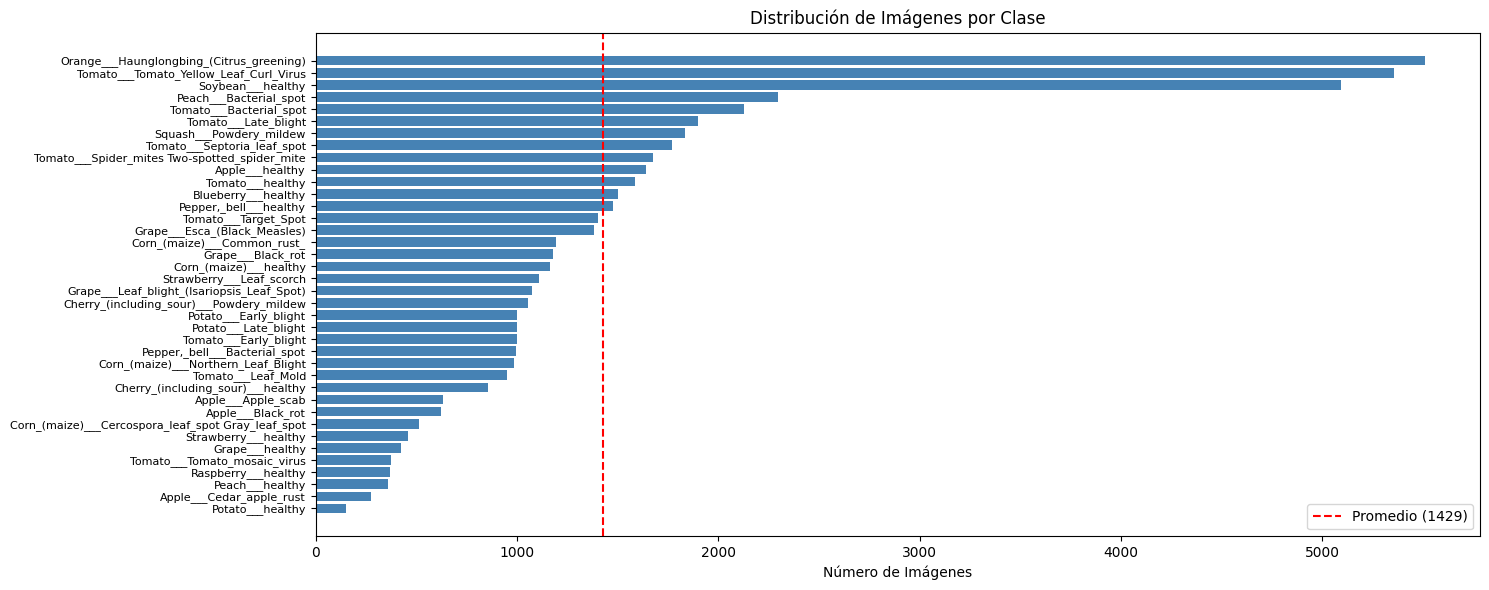


⚠️ Clases con representación baja (< 80% del promedio):
   20 clases requieren augmentation
   Potato___healthy                                  :   152 → necesita ~ 990 imágenes más
   Apple___Cedar_apple_rust                          :   275 → necesita ~ 867 imágenes más
   Peach___healthy                                   :   360 → necesita ~ 782 imágenes más
   Raspberry___healthy                               :   371 → necesita ~ 771 imágenes más
   Tomato___Tomato_mosaic_virus                      :   373 → necesita ~ 769 imágenes más
   Grape___healthy                                   :   423 → necesita ~ 719 imágenes más
   Strawberry___healthy                              :   456 → necesita ~ 686 imágenes más
   Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot:   513 → necesita ~ 629 imágenes más
   Apple___Black_rot                                 :   621 → necesita ~ 521 imágenes más
   Apple___Apple_scab                                :   630 → necesita ~ 512 imágenes m

In [12]:
def analyze_class_distribution(data_dir):
    """
    Analiza la distribución de imágenes por clase.
    """
    class_counts = {}

    for class_name in os.listdir(data_dir):
        class_path = os.path.join(data_dir, class_name)
        if os.path.isdir(class_path):
            img_files = [f for f in os.listdir(class_path)
                        if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            class_counts[class_name] = len(img_files)

    return class_counts

print("="*70)
print("PASO 2: ANÁLISIS DE DISTRIBUCIÓN DE CLASES")
print("="*70)

class_distribution = analyze_class_distribution(data_dir)
total_images = sum(class_distribution.values())
num_classes = len(class_distribution)

print(f"\n📊 Dataset Statistics:")
print(f"   Total de clases: {num_classes}")
print(f"   Total de imágenes: {total_images}")
print(f"   Promedio por clase: {total_images / num_classes:.1f}")

# Ordenar por cantidad de imágenes
sorted_classes = sorted(class_distribution.items(), key=lambda x: x[1])

print(f"\n📉 Top 10 clases con MENOS imágenes:")
for class_name, count in sorted_classes[:10]:
    print(f"   {class_name:50s}: {count:5d} imágenes ({count/total_images*100:.2f}%)")

print(f"\n📈 Top 10 clases con MÁS imágenes:")
for class_name, count in sorted_classes[-10:]:
    print(f"   {class_name:50s}: {count:5d} imágenes ({count/total_images*100:.2f}%)")

# Visualizar distribución
plt.figure(figsize=(15, 6))
classes_sorted = [c[0] for c in sorted_classes]
counts_sorted = [c[1] for c in sorted_classes]

plt.barh(range(len(classes_sorted)), counts_sorted, color='steelblue')
plt.yticks(range(len(classes_sorted)), classes_sorted, fontsize=8)
plt.xlabel('Número de Imágenes')
plt.title('Distribución de Imágenes por Clase')
plt.axvline(x=total_images/num_classes, color='red', linestyle='--',
            label=f'Promedio ({total_images/num_classes:.0f})')
plt.legend()
plt.tight_layout()
plt.show()

# Identificar clases con menos representación (< 80% del promedio)
threshold = 0.8 * (total_images / num_classes)
underrepresented_classes = {c: count for c, count in class_distribution.items()
                           if count < threshold}

print(f"\n⚠️ Clases con representación baja (< 80% del promedio):")
print(f"   {len(underrepresented_classes)} clases requieren augmentation")
for class_name, count in sorted(underrepresented_classes.items(), key=lambda x: x[1]):
    needed = int(threshold - count)
    print(f"   {class_name:50s}: {count:5d} → necesita ~{needed:4d} imágenes más")


## 3. Data Augmentation para Clases Desbalanceadas

Aplicamos augmentation selectivo solo a las clases con menor representación.
Esto balancea el dataset sin sobre-aumentar las clases ya bien representadas.


In [13]:
def create_augmentation_pipeline():
    """
    Crea un pipeline de augmentation. Se aplican: rotación de hasta 20 grados en amabas orientaciones;
    espejado de imagenes (horizontal y vertical); modificacion de brillo, contraste y saturación en un 20%;
    se mueve la imagen aleatoriamente en un 10% (horizontal y verticalmente); recorte aleatorio de entre un 80 y un 100%

    """
    return transforms.Compose([
        transforms.RandomRotation(20),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    ])

def augment_underrepresented_classes(data_dir, class_distribution, target_percentile=0.8):
    """
    Aumenta las clases con menos representación hasta alcanzar un umbral objetivo.

    Args:
        data_dir: Directorio raíz del dataset
        class_distribution: Dict con {clase: cantidad}
        target_percentile: Percentil objetivo (0.8 = 80% del promedio)
    """
    total_images = sum(class_distribution.values())
    num_classes = len(class_distribution)
    target_count = int(target_percentile * (total_images / num_classes))

    augmentation = create_augmentation_pipeline()
    total_generated = 0

    print("="*70)
    print("PASO 3: DATA AUGMENTATION SELECTIVO")
    print("="*70)
    print(f"Objetivo: ~{target_count} imágenes por clase")

    for class_name, current_count in tqdm(class_distribution.items(), desc="Procesando clases"):
        if current_count >= target_count:
            continue  # Clase ya tiene suficientes imágenes

        needed = target_count - current_count
        class_path = os.path.join(data_dir, class_name)

        # Obtener todas las imágenes de esta clase
        img_files = [f for f in os.listdir(class_path)
                    if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        if not img_files:
            continue

        # Generar data augmentation
        generated = 0
        while generated < needed:
            # Seleccionar imagen origen aleatoria
            source_img_name = np.random.choice(img_files)
            source_img_path = os.path.join(class_path, source_img_name)

            try:
                # Cargar y aumentar
                img = Image.open(source_img_path).convert('RGB')
                augmented_img = augmentation(img)

                # Guardar con nombre único
                base_name = os.path.splitext(source_img_name)[0]
                aug_name = f"{base_name}_aug_{generated}.jpg"
                aug_path = os.path.join(class_path, aug_name)

                augmented_img.save(aug_path)
                generated += 1
                total_generated += 1

            except Exception as e:
                print(f"Error augmentando {source_img_path}: {e}")
                continue

        print(f"  ✓ {class_name:50s}: +{generated} imágenes ({current_count} → {current_count + generated})")

    print(f"\n✅ Data Augmentation completado: {total_generated} nuevas imágenes generadas")

    return total_generated


PASO 3: DATA AUGMENTATION SELECTIVO
Objetivo: ~1142 imágenes por clase


Procesando clases:   8%|▊         | 3/38 [00:00<00:10,  3.40it/s]

  ✓ Pepper,_bell___Bacterial_spot                     : +145 imágenes (997 → 1142)


Procesando clases:  11%|█         | 4/38 [00:01<00:10,  3.16it/s]

  ✓ Grape___Leaf_blight_(Isariopsis_Leaf_Spot)        : +66 imágenes (1076 → 1142)


...

  ✓ Peach___healthy                                   : +782 imágenes (360 → 1142)


Procesando clases:  97%|█████████▋| 37/38 [00:43<00:02,  2.30s/it]

  ✓ Apple___Cedar_apple_rust                          : +867 imágenes (275 → 1142)


Procesando clases: 100%|██████████| 38/38 [00:44<00:00,  1.16s/it]

  ✓ Cherry_(including_sour)___Powdery_mildew          : +90 imágenes (1052 → 1142)

✅ Data Augmentation completado: 8641 nuevas imágenes generadas

DISTRIBUCIÓN DESPUÉS DE AUGMENTATION

📊 Nuevas estadísticas:
   Total de imágenes: 62925 (antes: 54284, +8641)
   Promedio por clase: 1655.9


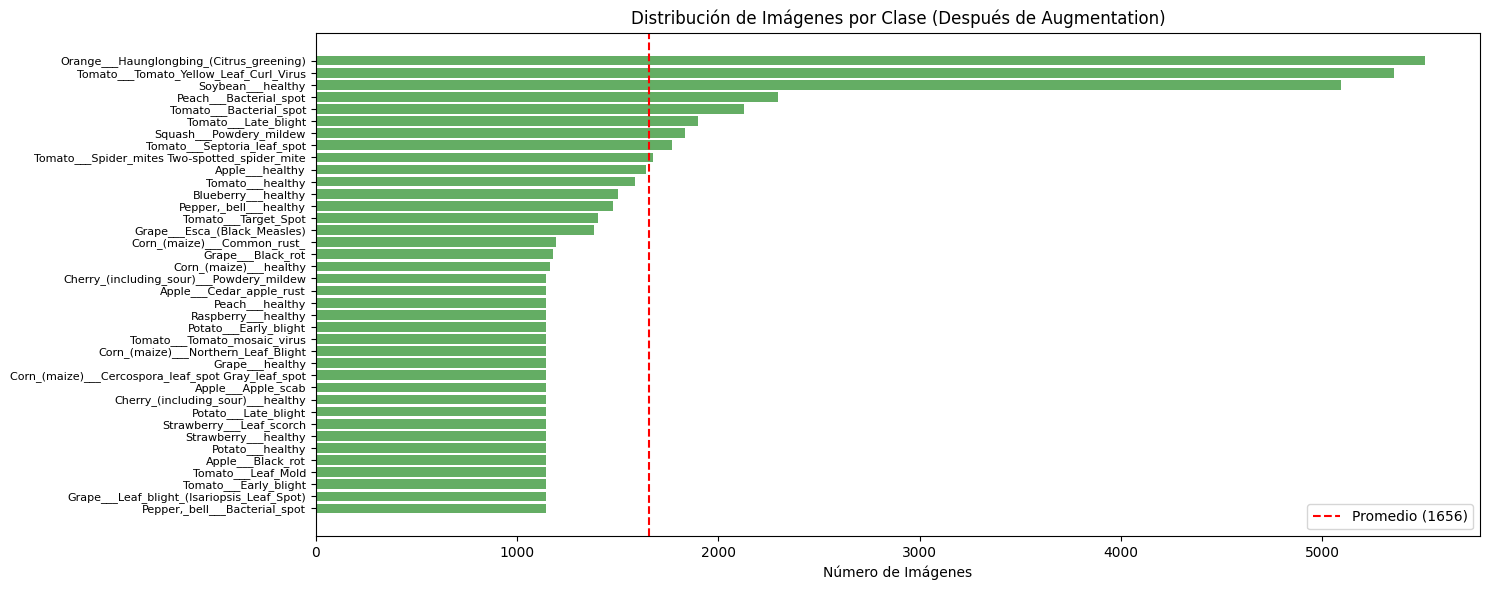

In [14]:
# Ejecutar data augmentation
generated_images = augment_underrepresented_classes(data_dir, class_distribution, target_percentile=0.8)

# Re-analizar distribución después del augmentation
print("\n" + "="*70)
print("DISTRIBUCIÓN DESPUÉS DE AUGMENTATION")
print("="*70)

new_distribution = analyze_class_distribution(data_dir)
new_total = sum(new_distribution.values())

print(f"\n📊 Nuevas estadísticas:")
print(f"   Total de imágenes: {new_total} (antes: {total_images}, +{new_total - total_images})")
print(f"   Promedio por clase: {new_total / num_classes:.1f}")

# Visualizar nueva distribución
plt.figure(figsize=(15, 6))
sorted_new = sorted(new_distribution.items(), key=lambda x: x[1])
classes_new = [c[0] for c in sorted_new]
counts_new = [c[1] for c in sorted_new]

plt.barh(range(len(classes_new)), counts_new, color='forestgreen', alpha=0.7)
plt.yticks(range(len(classes_new)), classes_new, fontsize=8)
plt.xlabel('Número de Imágenes')
plt.title('Distribución de Imágenes por Clase (Después de Augmentation)')
plt.axvline(x=new_total/num_classes, color='red', linestyle='--',
            label=f'Promedio ({new_total/num_classes:.0f})')
plt.legend()
plt.tight_layout()
plt.show()


## 4. Preparación de Datos y Transformaciones


In [15]:
# Transformaciones para train (con augmentation adicional ligero)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Transformaciones para val y test (sin augmentation)
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


## Funciones de Extracción de Características Numéricas

In [16]:
import cv2
import numpy as np
from PIL import Image
import torch

def get_color_proportions(image: Image.Image) -> np.ndarray:
    """
    Calcula las proporciones de amarillo y verde en una imagen PIL.
    """
    try:
        img_np = np.array(image.convert('RGB'))
        img_hsv = cv2.cvtColor(img_np, cv2.COLOR_RGB2HSV)

        # Definir rangos HSV para amarillo
        lower_yellow = np.array([20, 100, 100])
        upper_yellow = np.array([40, 255, 255])

        # Definir rangos HSV para verde
        lower_green = np.array([40, 40, 40])
        upper_green = np.array([80, 255, 255])

        mask_yellow = cv2.inRange(img_hsv, lower_yellow, upper_yellow)
        mask_green = cv2.inRange(img_hsv, lower_green, upper_green)

        # Considerar el total de píxeles de la imagen para la proporción
        total_pixels = img_np.shape[0] * img_np.shape[1]

        if total_pixels == 0:
            return np.array([0.0, 0.0])

        yellow_proportion = np.sum(mask_yellow > 0) / total_pixels
        green_proportion = np.sum(mask_green > 0) / total_pixels
        return np.array([yellow_proportion, green_proportion])
    except Exception as e:
        # print(f"Error en get_color_proportions: {e}") # Descomentar para depurar
        return np.array([0.0, 0.0])

def get_red_brown_stats(image: Image.Image) -> np.ndarray:
    """
    Calcula la proporción de rojo y marrón en una imagen PIL.
    """
    try:
        img_np = np.array(image.convert('RGB'))
        hsv = cv2.cvtColor(img_np, cv2.COLOR_RGB2HSV)

        # Rangos HSV para rojo (dos segmentos en el círculo de matiz)
        lower_red1 = np.array([0, 80, 50])
        upper_red1 = np.array([10, 255, 255])
        lower_red2 = np.array([170, 80, 50])
        upper_red2 = np.array([180, 255, 255])

        # Rango HSV para marrón (ejemplo, puede requerir ajuste)
        lower_brown = np.array([10, 80, 20])
        upper_brown = np.array([25, 255, 200])

        mask_red = cv2.bitwise_or(cv2.inRange(hsv, lower_red1, upper_red1),
                                  cv2.inRange(hsv, lower_red2, upper_red2))
        mask_brown = cv2.inRange(hsv, lower_brown, upper_brown)

        total_pixels = img_np.shape[0] * img_np.shape[1]

        if total_pixels == 0:
            return np.array([0.0, 0.0])

        red_proportion = np.sum(mask_red > 0) / total_pixels
        brown_proportion = np.sum(mask_brown > 0) / total_pixels
        return np.array([red_proportion, brown_proportion])
    except Exception as e:
        # print(f"Error en get_red_brown_stats: {e}") # Descomentar para depurar
        return np.array([0.0, 0.0])

def extract_rgb_statistics_detailed(image: Image.Image) -> np.ndarray:
    """
    Calcula la media y la desviación estándar de cada canal RGB de una imagen.
    Retorna un vector de 6 valores: [mean_R, std_R, mean_G, std_G, mean_B, std_B].
    """
    img_np = np.array(image.convert('RGB'))
    mean_r, mean_g, mean_b = np.mean(img_np[:, :, 0]), np.mean(img_np[:, :, 1]), np.mean(img_np[:, :, 2])
    std_r, std_g, std_b = np.std(img_np[:, :, 0]), np.std(img_np[:, :, 1]), np.std(img_np[:, :, 2])
    return np.array([mean_r, std_r, mean_g, std_g, mean_b, std_b])

def extract_all_color_features(image: Image.Image) -> np.ndarray:
    """
    Combina todas las características de color: proporciones (amarillo, verde, rojo, marrón)
    y estadísticas RGB (media y std).
    Retorna un vector de 10 valores.
    """
    yellow_green_props = get_color_proportions(image)
    red_brown_props = get_red_brown_stats(image)
    rgb_stats_detailed = extract_rgb_statistics_detailed(image)

    combined_features = np.concatenate(
        (yellow_green_props, red_brown_props, rgb_stats_detailed)
    )
    return combined_features

# Definir la dimensión de las características numéricas combinadas (4 proporciones + 6 RGB stats)
numerical_features_dim = 10

print("Funciones de extracción de características numéricas actualizadas. numerical_features_dim:"
      f" {numerical_features_dim}")

Funciones de extracción de características numéricas actualizadas. numerical_features_dim: 10


Clase Custom PlantImageDataset para agregar caracteristicas de distribución de color

In [17]:
from torch.utils.data import Dataset, Subset
from torchvision import datasets
from PIL import Image
import os
import torch

class PlantImageDataset(Dataset):
    def __init__(self, base_dataset, transform=None):
        self.base_dataset = base_dataset
        self.transform = transform

        if isinstance(base_dataset, Subset):
            self.samples = [(base_dataset.dataset.samples[i][0], base_dataset.dataset.samples[i][1]) for i in base_dataset.indices]
            self.classes = base_dataset.dataset.classes
        elif isinstance(base_dataset, datasets.ImageFolder):
            self.samples = base_dataset.samples
            self.classes = base_dataset.classes
        elif isinstance(base_dataset, PlantImageDataset):
            self.samples = base_dataset.samples
            self.classes = base_dataset.classes
            self.transform = base_dataset.transform
        else:
            raise TypeError("base_dataset debe ser torchvision.datasets.ImageFolder, torch.utils.data.Subset o PlantImageDataset")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        original_image = Image.open(img_path).convert('RGB')

        # *** Nueva función combinada de extracción de características ***
        all_features = extract_all_color_features(original_image)

        numerical_features = torch.tensor(
            all_features.tolist(),
            dtype=torch.float32
        )

        transformed_image = self.transform(original_image) if self.transform else original_image

        return transformed_image, numerical_features, label

print("Clase PlantImageDataset definida y actualizada para las nuevas características de color.")

Clase PlantImageDataset definida y actualizada para las nuevas características de color.


## 5. Partición Estratificada del Dataset


In [18]:
def stratified_split_indices(indices, labels, train_frac=0.8, val_frac=0.1, test_frac=0.1, rng=None):
    """
    Divide los índices de forma estratificada por clase.
    """
    if rng is None:
        rng = np.random.RandomState(0)

    train_idxs, val_idxs, test_idxs = [], [], []

    # Agrupar por clase
    class_to_idxs = {}
    for i in indices:
        class_to_idxs.setdefault(labels[i], []).append(i)

    # Dividir cada clase
    for cls, idxs in class_to_idxs.items():
        idxs = list(idxs)
        rng.shuffle(idxs)
        n = len(idxs)

        n_train = int(train_frac * n)
        n_val = int(val_frac * n)

        train_idxs.extend(idxs[:n_train])
        val_idxs.extend(idxs[n_train:n_train + n_val])
        test_idxs.extend(idxs[n_train + n_val:])

    return train_idxs, val_idxs, test_idxs

# Re-crear full_dataset_base sin transformaciones para que PlantImageDataset las aplique
full_dataset_base = datasets.ImageFolder(root=data_dir)
labels = [label for _, label in full_dataset_base.samples]
num_classes = len(full_dataset_base.classes) # Asegurar que num_classes esté correctamente definido

rng = np.random.RandomState(42)

if test_execution:
    # Subset reducido para pruebas
    subset_indices = []
    reduction_factor = 0.1

    for class_idx in range(num_classes):
        class_indices = [i for i, (_, label) in enumerate(full_dataset_base.samples) if label == class_idx]
        n_samples = max(1, int(len(class_indices) * reduction_factor))
        chosen = rng.choice(class_indices, n_samples, replace=False).tolist()
        subset_indices.extend(chosen)

    rng.shuffle(subset_indices)
    train_indices, val_indices, test_indices = stratified_split_indices(
        subset_indices, labels, train_frac=0.8, val_frac=0.1, test_frac=0.1, rng=rng
    )

    # Envolver los Subsets base con PlantImageDataset y aplicar las transformaciones
    train_dataset = PlantImageDataset(Subset(full_dataset_base, train_indices), transform=train_transform)
    val_dataset = PlantImageDataset(Subset(full_dataset_base, val_indices), transform=val_transform)
    test_dataset = PlantImageDataset(Subset(full_dataset_base, test_indices), transform=test_transform)
else:
    # Dataset completo
    all_indices = list(range(len(full_dataset_base)))
    train_indices, val_indices, test_indices = stratified_split_indices(
        all_indices, labels, train_frac=0.8, val_frac=0.1, test_frac=0.1, rng=rng
    )

    # Envolver los Subsets base con PlantImageDataset y aplicar las transformaciones
    train_dataset = PlantImageDataset(Subset(full_dataset_base, train_indices), transform=train_transform)
    val_dataset = PlantImageDataset(Subset(full_dataset_base, val_indices), transform=val_transform)
    test_dataset = PlantImageDataset(Subset(full_dataset_base, test_indices), transform=test_transform)

print(f"✅ Dataset preparado (con características numéricas):")
print(f"   Clases: {num_classes}")
print(f"   Train: {len(train_dataset)}")
print(f"   Val: {len(val_dataset)}")
print(f"   Test: {len(test_dataset)}")

# === Actualización para subsets de Optuna ===
# La variable `subset_fraction` debería estar definida en alguna celda anterior (WoRdXI-dPv25),
# pero si no, asegúrate de definirla aquí, por ejemplo: `subset_fraction = 0.3`
if 'subset_fraction' not in locals():
    subset_fraction = 0.3 # Definir por si acaso no está cargado.

# Obtenemos las etiquetas de los `PlantImageDataset` de entrenamiento y validación completos
# para crear subsets estratificados. Necesitamos los índices originales de estos datasets.

# Creamos una lista de índices del 0 a len(train_dataset)-1
train_full_indices = list(range(len(train_dataset)))
val_full_indices = list(range(len(val_dataset)))


# Obtenemos las etiquetas desde el `samples` de cada `PlantImageDataset`.
# `s[1]` es la etiqueta en `(img_path, label)`
train_labels_for_optuna_split = [s[1] for s in train_dataset.samples]
val_labels_for_optuna_split = [s[1] for s in val_dataset.samples]

# Creamos subsets estratificados del *PlantImageDataset* completo de entrenamiento y validación
# La función `stratified_split_indices` espera una lista de todos los índices y sus etiquetas correspondientes.
# Luego devuelve los índices para train, val, test.

# Para Optuna, crearemos los Subset de los *índices* de los PlantImageDataset actuales.
rng_optuna = np.random.RandomState(42) # Asegurar reproducibilidad para Optuna subsets

# Usamos stratified_split_indices para obtener los índices para los subsets de Optuna
# Necesitamos pasar los índices del dataset completo (0 a len-1) y las etiquetas correspondientes.
# El tercer retorno de stratified_split_indices ([2]) es el 'test_idxs' que usaremos como nuestro subset.

# train_dataset_optuna será un Subset de train_dataset (que ya es un PlantImageDataset)
train_optuna_indices_for_subset, _, _ = stratified_split_indices(
    list(range(len(train_dataset))), train_labels_for_optuna_split,
    train_frac=subset_fraction, val_frac=0, test_frac=1-subset_fraction, rng=rng_optuna
)
val_optuna_indices_for_subset, _, _ = stratified_split_indices(
    list(range(len(val_dataset))), val_labels_for_optuna_split,
    train_frac=subset_fraction, val_frac=0, test_frac=1-subset_fraction, rng=rng_optuna
)

# Creamos los nuevos `PlantImageDataset` de Optuna a partir de los `train_dataset` y `val_dataset` completos
train_dataset_optuna = PlantImageDataset(Subset(train_dataset, train_optuna_indices_for_subset), transform=train_transform)
val_dataset_optuna = PlantImageDataset(Subset(val_dataset, val_optuna_indices_for_subset), transform=val_transform)

print(f"\n✅ Subsets creados para Optuna (con características numéricas):")
print(f"   Train subset: {len(train_dataset_optuna)} imágenes ({len(train_dataset_optuna)/len(train_dataset)*100:.1f}% del original)")
print(f"   Val subset: {len(val_dataset_optuna)} imágenes ({len(val_dataset_optuna)/len(val_dataset)*100:.1f}% del original)")


✅ Dataset preparado (con características numéricas):
   Clases: 38
   Train: 50320
   Val: 6281
   Test: 6324

✅ Subsets creados para Optuna (con características numéricas):
   Train subset: 15070 imágenes (29.9% del original)
   Val subset: 1873 imágenes (29.8% del original)


## 6. Funciones de Utilidad: Training y Evaluación


In [19]:
def train_model(model, dataloaders, criterion, optimizer, num_epochs=5, patience=3, device='cuda'):
    """
    Entrena un modelo con early stopping, ahora aceptando características numéricas.
    """
    since = time.time()

    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'train_recall': [], 'val_recall': [],
        'train_f1': [], 'val_f1': [],
        'train_auc_pr': [], 'val_auc_pr': []
    }

    model.to(device)
    best_metric = -np.inf
    best_model_wts = copy.deepcopy(model.state_dict())
    counter = 0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            all_labels = []
            all_preds = []
            all_probs = []

            # El DataLoader ahora entrega imagen, características numéricas y etiquetas
            for inputs, numerical_features, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                numerical_features = numerical_features.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    # Pasar imagen y características numéricas al modelo
                    outputs = model(inputs, numerical_features)
                    probs = torch.softmax(outputs, dim=1)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                all_labels.extend(labels.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())
                all_probs.append(probs.detach().cpu().numpy())

            all_probs = np.vstack(all_probs)

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = accuracy_score(all_labels, all_preds)
            epoch_recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
            epoch_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
            # LabelBinarizer es necesario para average_precision_score con múltiples clases
            lb = LabelBinarizer()
            lb.fit(range(len(dataloaders[phase].dataset.classes)))
            auc_pr = average_precision_score(lb.transform(all_labels), all_probs, average='macro')

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} '
                  f'Recall: {epoch_recall:.4f} F1: {epoch_f1:.4f} AUC-PR: {auc_pr:.4f}')

            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc)
                history['train_recall'].append(epoch_recall)
                history['train_f1'].append(epoch_f1)
                history['train_auc_pr'].append(auc_pr)
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc)
                history['val_recall'].append(epoch_recall)
                history['val_f1'].append(epoch_f1)
                history['val_auc_pr'].append(auc_pr)

        # Early stopping
        epoch_metric = history['val_f1'][-1]  # Usamos F1 como métrica principal

        if epoch_metric > best_metric:
            best_metric = epoch_metric
            counter = 0
            best_model_wts = copy.deepcopy(model.state_dict())
        else:
            counter += 1
            if counter >= patience:
                print(f"Early stopping en epoch {epoch+1}")
                break

    time_elapsed = time.time() - since
    print(f'\nEntrenamiento completado en {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Mejor F1 validation: {best_metric:.4f}')

    # Cargar los mejores pesos
    model.load_state_dict(best_model_wts)

    return model, history, time_elapsed


def evaluate_model(model, dataloader, device='cpu'):
    """
    Evalúa un modelo en un conjunto de datos, ahora aceptando características numéricas.
    """
    model.to(device)
    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []

    start_time = time.time()

    with torch.no_grad():
        # El DataLoader ahora entrega imagen, características numéricas y etiquetas
        for inputs, numerical_features, labels in dataloader:
            inputs = inputs.to(device)
            numerical_features = numerical_features.to(device)
            labels = labels.to(device)

            # Pasar imagen y características numéricas al modelo
            outputs = model(inputs, numerical_features)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.append(probs.cpu().numpy())

    inference_time = time.time() - start_time
    all_probs = np.vstack(all_probs)

    accuracy = accuracy_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    # LabelBinarizer es necesario para average_precision_score con múltiples clases
    lb = LabelBinarizer()
    lb.fit(range(len(dataloader.dataset.classes)))
    auc_pr = average_precision_score(lb.transform(all_labels), all_probs, average='macro')

    return accuracy, recall, f1, auc_pr, inference_time


def get_model_size(model, model_name="model"):
    """
    Calcula el tamaño del modelo en disco.
    """
    torch.save(model.state_dict(), f"{model_name}.pth")
    size_mb = os.path.getsize(f"{model_name}.pth") / 1e6
    os.remove(f"{model_name}.pth")
    return size_mb


def plot_history(history, title="Training History"):
    """
    Grafica las métricas de entrenamiento.
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    metrics = [('loss', 'Loss'), ('acc', 'Accuracy'), ('recall', 'Recall'),
               ('f1', 'F1 Score'), ('auc_pr', 'AUC-PR')]

    for idx, (metric, label) in enumerate(metrics):
        row = idx // 3
        col = idx % 3

        axes[row, col].plot(history[f'train_{metric}'], label='Train', marker='o')
        axes[row, col].plot(history[f'val_{metric}'], label='Validation', marker='s')
        axes[row, col].set_xlabel('Epoch')
        axes[row, col].set_ylabel(label)
        axes[row, col].set_title(f'{label} Over Time')
        axes[row, col].legend()
        axes[row, col].grid(True, alpha=0.3)

    # Ocultar el último subplot vacío
    axes[1, 2].axis('off')

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

print("Funciones train_model, evaluate_model, get_model_size y plot_history actualizadas.")


Funciones train_model, evaluate_model, get_model_size y plot_history actualizadas.


## 7. Búsqueda de Hiperparámetros con Optuna

Utilizamos Optuna para encontrar los mejores hiperparámetros:
- Learning rate
- Batch size
- Arquitectura del clasificador (número de capas y neuronas)
- Optimizer (SGD vs Adam)
- Weight decay

**Nota:** Para acelerar la búsqueda, usamos solo el **30% del dataset** en los trials de Optuna.


#### Funciones

In [20]:
# Crear subsets del 30% para búsqueda de hiperparámetros (acelera el proceso)
print("="*70)
print("PREPARANDO SUBSETS PARA BÚSQUEDA DE HIPERPARÁMETROS")
print("="*70)

subset_fraction = 0.3  # Usar 30% del dataset

# Obtener labels de los datasets
if isinstance(train_dataset, Subset):
    train_labels = [train_dataset.dataset.targets[i] for i in train_dataset.indices]
    val_labels = [val_dataset.dataset.targets[i] for i in val_dataset.indices]
else:
    train_labels = [label for _, label in train_dataset.samples]
    val_labels = [label for _, label in val_dataset.samples]

# Crear subsets estratificados del 30%
def create_stratified_subset(dataset, labels, fraction, rng):
    """Crea un subset estratificado por clase."""
    class_to_idxs = {}
    for i, label in enumerate(labels):
        class_to_idxs.setdefault(label, []).append(i)

    subset_indices = []
    for class_label, indices in class_to_idxs.items():
        n_samples = max(1, int(len(indices) * fraction))
        chosen = rng.choice(indices, n_samples, replace=False).tolist()
        subset_indices.extend(chosen)

    rng.shuffle(subset_indices)
    return subset_indices

rng_optuna = np.random.RandomState(42)

# Crear índices para subsets
train_subset_indices = create_stratified_subset(train_dataset, train_labels, subset_fraction, rng_optuna)
val_subset_indices = create_stratified_subset(val_dataset, val_labels, subset_fraction, rng_optuna)

# Crear los subsets
if isinstance(train_dataset, Subset):
    # Si ya es un Subset, necesitamos mapear los índices
    train_optuna_indices = [train_dataset.indices[i] for i in train_subset_indices]
    val_optuna_indices = [val_dataset.indices[i] for i in val_subset_indices]

    train_dataset_optuna = Subset(train_dataset.dataset, train_optuna_indices)
    val_dataset_optuna = Subset(val_dataset.dataset, val_optuna_indices)
else:
    train_dataset_optuna = Subset(train_dataset, train_subset_indices)
    val_dataset_optuna = Subset(val_dataset, val_subset_indices)

print(f"\n✅ Subsets creados para Optuna:")
print(f"   Train subset: {len(train_dataset_optuna)} imágenes ({len(train_dataset_optuna)/len(train_dataset)*100:.1f}% del original)")
print(f"   Val subset: {len(val_dataset_optuna)} imágenes ({len(val_dataset_optuna)/len(val_dataset)*100:.1f}% del original)")
print("="*70)


PREPARANDO SUBSETS PARA BÚSQUEDA DE HIPERPARÁMETROS

✅ Subsets creados para Optuna:
   Train subset: 15070 imágenes (29.9% del original)
   Val subset: 1873 imágenes (29.8% del original)


In [21]:
import torch.nn as nn
import torch.nn.functional as F

class CombinedFeaturesModel(nn.Module):
    def __init__(self, backbone, num_classes, numerical_features_dim, hidden_dim=512, num_layers=1, dropout=0.2):
        super(CombinedFeaturesModel, self).__init__()
        self.backbone = backbone

        # Congelar features del backbone
        for param in self.backbone.features.parameters():
            param.requires_grad = False

        # Determinar el tamaño de la salida aplanada del backbone
        # Usamos un tensor dummy para pasar por el backbone y obtener su forma de salida
        dummy_input = torch.randn(1, 3, 224, 224)
        with torch.no_grad():
            features_output = self.backbone.features(dummy_input)
            # Aplicar pooling si existe y si no es un MobileNetV3 small que usa adaptive_avg_pool2d directamente en forward
            if hasattr(self.backbone, 'avgpool') and isinstance(self.backbone.avgpool, nn.AdaptiveAvgPool2d):
                features_output = self.backbone.avgpool(features_output)
            elif features_output.dim() == 4 and features_output.shape[2] == 7 and features_output.shape[3] == 7: # Asumir salida como (N, C, 7, 7)
                 features_output = F.adaptive_avg_pool2d(features_output, (1, 1))

        flattened_features_size = torch.flatten(features_output, 1).size(1)

        # El tamaño combinado de entrada para el clasificador será la salida aplanada del backbone
        # más la dimensión de las características numéricas.
        self.combined_in_features = flattened_features_size + numerical_features_dim

        # Crear capa de clasificador
        if num_layers == 1:
            self.custom_classifier = nn.Sequential(
                nn.Linear(self.combined_in_features, num_classes)
            )
        elif num_layers == 2:
            self.custom_classifier = nn.Sequential(
                nn.Linear(self.combined_in_features, hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_dim, num_classes)
            )
        else:  # 3 layers
            self.custom_classifier = nn.Sequential(
                nn.Linear(self.combined_in_features, hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_dim, hidden_dim // 2),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_dim // 2, num_classes)
            )

    def forward(self, image_tensor, numerical_features_tensor):
        # Pasar la imagen por el backbone
        x = self.backbone.features(image_tensor)
        # Aplicar pooling del backbone si es aplicable (maneja MobileNetV2 y V3 small)
        if hasattr(self.backbone, 'avgpool') and isinstance(self.backbone.avgpool, nn.AdaptiveAvgPool2d):
            x = self.backbone.avgpool(x)
        elif x.dim() == 4 and x.shape[2] == 7 and x.shape[3] == 7: # Asumir salida como (N, C, 7, 7)
             x = F.adaptive_avg_pool2d(x, (1, 1))

        x = torch.flatten(x, 1)

        # Concatenar características de la imagen con las características numéricas
        x = torch.cat((x, numerical_features_tensor), dim=1)

        # Pasar la salida combinada al clasificador personalizado
        return self.custom_classifier(x)

def create_model_with_custom_classifier(
    backbone_model,
    num_classes,
    numerical_features_dim, # Nuevo argumento
    hidden_dim=512,
    num_layers=1,
    dropout=0.2
):
    """
    Crea un modelo preentrenado con clasificador, integrando características numéricas.
    Retorna una instancia de CombinedFeaturesModel.
    """
    return CombinedFeaturesModel(
        backbone=backbone_model,
        num_classes=num_classes,
        numerical_features_dim=numerical_features_dim,
        hidden_dim=hidden_dim,
        num_layers=num_layers,
        dropout=dropout
    )

# --- Función objective para Optuna (también modificada) ---
def objective(trial, modelo_preentrenado, train_dataset, val_dataset):
    """
    Función objetivo para Optuna, ahora aceptando características numéricas.
    Usa un subset para acelerar la búsqueda.
    """
    print(f"Trial {trial.number} iniciado")

    # Hiperparámetros a optimizar
    lr = trial.suggest_float('lr', 1e-4, 1e-1, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
    hidden_dim = trial.suggest_categorical('hidden_dim', [256, 512, 1024])
    num_layers = trial.suggest_int('num_layers', 1, 3)
    dropout = trial.suggest_float('dropout', 0.1, 0.5)
    optimizer_name = trial.suggest_categorical('optimizer', ['SGD', 'Adam'])
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)

    # Crear dataloaders con el batch_size sugerido usando los SUBSETS
    trial_dataloaders = {
        'train': DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          num_workers=5, prefetch_factor=2, pin_memory=True,
                            persistent_workers=False),
        'val': DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                        num_workers=5, prefetch_factor=2, pin_memory=True,
                          persistent_workers=False)
    }

    # Crear modelo usando la nueva función create_model_with_custom_classifier
    # Necesita un 'backbone_model' nuevo cada vez para evitar compartir pesos o estados
    if isinstance(modelo_preentrenado, torchvision.models.MobileNetV2):
      base_model_fresh = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
    elif isinstance(modelo_preentrenado, torchvision.models.MobileNetV3):
      base_model_fresh = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
    else:
      # Manejar otros modelos o lanzar error si el tipo no es esperado.
      # Para un caso general, podrías crear una nueva instancia del modelo preentrenado sin pesos
      # y cargar los pesos si es necesario, o pasar una función constructora al objective.
      raise ValueError(f"Tipo de modelo backbone no reconocido para Optuna: {type(modelo_preentrenado)}")


    model = create_model_with_custom_classifier(
        backbone_model=base_model_fresh,
        num_classes=num_classes,
        numerical_features_dim=numerical_features_dim,
        hidden_dim=hidden_dim,
        num_layers=num_layers,
        dropout=dropout
    )

    # Configurar optimizer y criterion (sin cambios aquí)
    criterion = nn.CrossEntropyLoss()

    # Asegurar que el optimizador solo actualice los parámetros del clasificador personalizado
    if optimizer_name == 'SGD':
        # Los parámetros del clasificador están en model.custom_classifier
        optimizer = optim.SGD(model.custom_classifier.parameters(), lr=lr,
                            momentum=0.9, weight_decay=weight_decay)
    else:
        optimizer = optim.Adam(model.custom_classifier.parameters(), lr=lr,
                             weight_decay=weight_decay)

    # Entrenar por pocas épocas para evaluar rápido (sin cambios aquí)
    model.to(device)
    model.train()

    num_epochs_trial = 5  # Pocas épocas para cada trial

    for epoch in range(num_epochs_trial):
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            all_labels = []
            all_preds = []
            all_probs = []

            # El DataLoader ahora entrega imagen, características numéricas y etiquetas
            for inputs, numerical_features, labels in trial_dataloaders[phase]:
                inputs = inputs.to(device)
                numerical_features = numerical_features.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    # Pasar imagen y características numéricas al modelo
                    outputs = model(inputs, numerical_features)
                    _, preds = torch.max(outputs, 1)
                    probs = torch.softmax(outputs, dim=1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                all_labels.extend(labels.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())
                all_probs.append(probs.detach().cpu().numpy())

        all_probs = np.vstack(all_probs)

        # Calcular F1 y AUC-PR en validación
        val_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
        lb = LabelBinarizer()
        # Asegurarse de que el binarizer tenga todas las clases posibles si no están presentes en el subset
        lb.fit(range(num_classes))
        val_auc_pr = average_precision_score(lb.transform(all_labels), all_probs, average='macro')

        trial.report(val_auc_pr, epoch)

        if trial.should_prune():
            raise optuna.TrialPruned()

    return val_auc_pr # Retornar AUC PR final de validación

In [22]:
def run_optuna_search(
    modelo_preentrenado,
    objective,
    train_dataset_optuna,
    val_dataset_optuna,
    subset_fraction=0.2,
    n_trials=10,
    seed=42
):
    print("="*70)
    print(f"BÚSQUEDA DE HIPERPARÁMETROS CON OPTUNA ({subset_fraction*100}% del dataset)")
    print("="*70)

    # Crear estudio
    study = optuna.create_study(
        direction='maximize',  # Optimizar AUC PR
        pruner=optuna.pruners.MedianPruner(
            n_startup_trials=3,
            n_warmup_steps=2
        ),
        sampler=optuna.samplers.TPESampler(seed=seed)
    )

    # Aviso
    print(f"\n🔍 Ejecutando {n_trials} trials de optimización...")
    print(f"   Usando {len(train_dataset_optuna)} imágenes de train "
          f"({subset_fraction*100:.0f}% del total)")
    print(f"   Usando {len(val_dataset_optuna)} imágenes de validación "
          f"({subset_fraction*100:.0f}% del total)")

    # 👉 Pasar el modelo mediante lambda
    study.optimize(
        lambda trial: objective(
            trial,
            modelo_preentrenado=modelo_preentrenado,
            train_dataset=train_dataset_optuna,
            val_dataset=val_dataset_optuna
        ),
        n_trials=n_trials,
        show_progress_bar=True
    )

    # Mostrar resultados
    print("\n" + "="*70)
    print("RESULTADOS DE LA OPTIMIZACIÓN")
    print("="*70)

    print(f"\n🏆 Mejor AUC PR: {study.best_value:.4f}")
    print(f"\n📋 Mejores hiperparámetros:")
    for key, value in study.best_params.items():
        print(f"   {key:15s}: {value}")

    # Importancia de parámetros
    try:
        fig = optuna.visualization.plot_param_importances(study)
        fig.show()
    except:
        print("\n⚠️ No se pudo generar gráfico de importancia (requiere plotly)")

    # Historial
    try:
        fig = optuna.visualization.plot_optimization_history(study)
        fig.show()
    except:
        print("⚠️ No se pudo generar gráfico de historia")

    print(f"\n✅ Hiperparámetros óptimos guardados")
    print(f"\n💡 Nota: Estos hiperparámetros fueron encontrados usando {subset_fraction*100:.0f}% del dataset.")

    return study.best_params, study


#### Búsqueda

In [ ]:
best_params_v2, study_v2 = run_optuna_search(
    modelo_preentrenado = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1),
    objective = objective,
    train_dataset_optuna = train_dataset_optuna,
    val_dataset_optuna = val_dataset_optuna,
    subset_fraction = 0.3,
    n_trials=30,
    seed = 100
)

```
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth
100%|██████████| 13.6M/13.6M [00:00<00:00, 83.2MB/s]
[I 2025-12-13 19:31:39,644] A new study created in memory with name: no-name-4c10d354-3e4c-4af7-98d2-50b1f8770af8
======================================================================
BÚSQUEDA DE HIPERPARÁMETROS CON OPTUNA (30.0% del dataset)
======================================================================

🔍 Ejecutando 30 trials de optimización...
   Usando 15070 imágenes de train (30% del total)
   Usando 1873 imágenes de validación (30% del total)
Best trial: 11. Best value: 0.983518: 100%
 30/30 [40:46<00:00, 70.52s/it]
Trial 0 iniciado
[I 2025-12-13 19:33:23,430] Trial 0 finished with value: 0.9660939647816024 and parameters: {'lr': 0.004267905801362681, 'batch_size': 128, 'hidden_dim': 1024, 'num_layers': 3, 'dropout': 0.1546826358739812, 'optimizer': 'Adam', 'weight_decay': 4.242348737644766e-06}. Best is trial 0 with value: 0.9660939647816024.
Trial 1 iniciado
[I 2025-12-13 19:35:03,616] Trial 1 finished with value: 0.8234443474603278 and parameters: {'lr': 0.00035973662732008367, 'batch_size': 128, 'hidden_dim': 1024, 'num_layers': 1, 'dropout': 0.2726816734652487, 'optimizer': 'SGD', 'weight_decay': 1.0193793939126967e-05}. Best is trial 0 with value: 0.9660939647816024.
Trial 2 iniciado
[I 2025-12-13 19:36:43,323] Trial 2 finished with value: 0.6048536636407469 and parameters: {'lr': 0.0003359165190266902, 'batch_size': 32, 'hidden_dim': 256, 'num_layers': 2, 'dropout': 0.14205907416482255, 'optimizer': 'SGD', 'weight_decay': 0.0004690667947587052}. Best is trial 0 with value: 0.9660939647816024.
Trial 3 iniciado
[I 2025-12-13 19:38:21,997] Trial 3 finished with value: 0.9325054282614373 and parameters: {'lr': 0.08765214954875089, 'batch_size': 64, 'hidden_dim': 256, 'num_layers': 1, 'dropout': 0.18401063106914425, 'optimizer': 'Adam', 'weight_decay': 5.650484493231643e-06}. Best is trial 0 with value: 0.9660939647816024.
Trial 4 iniciado
[I 2025-12-13 19:39:21,446] Trial 4 pruned.
Trial 5 iniciado
[I 2025-12-13 19:41:00,251] Trial 5 finished with value: 0.9826455961701527 and parameters: {'lr': 0.00134510864185965, 'batch_size': 64, 'hidden_dim': 512, 'num_layers': 2, 'dropout': 0.24527520164373995, 'optimizer': 'Adam', 'weight_decay': 5.490446241606575e-06}. Best is trial 5 with value: 0.9826455961701527.
Trial 6 iniciado
[I 2025-12-13 19:42:39,336] Trial 6 finished with value: 0.9803628194536603 and parameters: {'lr': 0.00033175998691021305, 'batch_size': 32, 'hidden_dim': 256, 'num_layers': 2, 'dropout': 0.3034795572952776, 'optimizer': 'Adam', 'weight_decay': 0.000947270711271214}. Best is trial 5 with value: 0.9826455961701527.
Trial 7 iniciado
[I 2025-12-13 19:44:17,396] Trial 7 finished with value: 0.9831389115689211 and parameters: {'lr': 0.0015314675366880019, 'batch_size': 64, 'hidden_dim': 512, 'num_layers': 1, 'dropout': 0.14431516047297832, 'optimizer': 'Adam', 'weight_decay': 9.480259180835892e-05}. Best is trial 7 with value: 0.9831389115689211.
Trial 8 iniciado
[I 2025-12-13 19:45:18,191] Trial 8 pruned.
Trial 9 iniciado
[I 2025-12-13 19:46:17,521] Trial 9 pruned.
Trial 10 iniciado
[I 2025-12-13 19:47:16,770] Trial 10 pruned.
Trial 11 iniciado
[I 2025-12-13 19:48:54,696] Trial 11 finished with value: 0.9835182441825483 and parameters: {'lr': 0.0020601531857269355, 'batch_size': 64, 'hidden_dim': 512, 'num_layers': 1, 'dropout': 0.22926983808753784, 'optimizer': 'Adam', 'weight_decay': 1.6386558231281613e-05}. Best is trial 11 with value: 0.9835182441825483.
Trial 12 iniciado
[I 2025-12-13 19:50:34,231] Trial 12 finished with value: 0.9786445868001032 and parameters: {'lr': 0.013896429858363955, 'batch_size': 64, 'hidden_dim': 512, 'num_layers': 1, 'dropout': 0.22056173784489608, 'optimizer': 'Adam', 'weight_decay': 1.1133928971572163e-06}. Best is trial 11 with value: 0.9835182441825483.
Trial 13 iniciado
[I 2025-12-13 19:52:13,076] Trial 13 finished with value: 0.9814835495800641 and parameters: {'lr': 0.001855823567429003, 'batch_size': 64, 'hidden_dim': 512, 'num_layers': 1, 'dropout': 0.10052556364279036, 'optimizer': 'Adam', 'weight_decay': 2.3632643657851444e-05}. Best is trial 11 with value: 0.9835182441825483.
Trial 14 iniciado
[I 2025-12-13 19:53:13,384] Trial 14 pruned.
Trial 15 iniciado
[I 2025-12-13 19:54:13,816] Trial 15 pruned.
Trial 16 iniciado
[I 2025-12-13 19:55:55,741] Trial 16 finished with value: 0.981931361722213 and parameters: {'lr': 0.002070897713714866, 'batch_size': 64, 'hidden_dim': 512, 'num_layers': 1, 'dropout': 0.21625525073702936, 'optimizer': 'Adam', 'weight_decay': 0.00027225773829735346}. Best is trial 11 with value: 0.9835182441825483.
Trial 17 iniciado
[I 2025-12-13 19:56:56,498] Trial 17 pruned.
Trial 18 iniciado
[I 2025-12-13 19:57:56,871] Trial 18 pruned.
Trial 19 iniciado
[I 2025-12-13 19:59:37,846] Trial 19 finished with value: 0.9828587665233978 and parameters: {'lr': 0.003125851155813724, 'batch_size': 128, 'hidden_dim': 1024, 'num_layers': 1, 'dropout': 0.197936921042007, 'optimizer': 'Adam', 'weight_decay': 2.0334337581944404e-06}. Best is trial 11 with value: 0.9835182441825483.
Trial 20 iniciado
[I 2025-12-13 20:00:37,475] Trial 20 pruned.
Trial 21 iniciado
[I 2025-12-13 20:02:19,703] Trial 21 finished with value: 0.9835017288915844 and parameters: {'lr': 0.0034881335662228026, 'batch_size': 128, 'hidden_dim': 1024, 'num_layers': 1, 'dropout': 0.1920003153418886, 'optimizer': 'Adam', 'weight_decay': 1.4352490902174124e-06}. Best is trial 11 with value: 0.9835182441825483.
Trial 22 iniciado
[I 2025-12-13 20:03:20,491] Trial 22 pruned.
Trial 23 iniciado
[I 2025-12-13 20:05:01,148] Trial 23 finished with value: 0.9825955339696462 and parameters: {'lr': 0.0025814797110451245, 'batch_size': 128, 'hidden_dim': 1024, 'num_layers': 1, 'dropout': 0.2714054566737857, 'optimizer': 'Adam', 'weight_decay': 5.7098831433606934e-05}. Best is trial 11 with value: 0.9835182441825483.
Trial 24 iniciado
[I 2025-12-13 20:06:22,378] Trial 24 pruned.
Trial 25 iniciado
[I 2025-12-13 20:08:03,116] Trial 25 finished with value: 0.982158596469377 and parameters: {'lr': 0.0014907766092849093, 'batch_size': 128, 'hidden_dim': 1024, 'num_layers': 1, 'dropout': 0.12765961073673956, 'optimizer': 'Adam', 'weight_decay': 1.1773769998560947e-05}. Best is trial 11 with value: 0.9835182441825483.
Trial 26 iniciado
[I 2025-12-13 20:09:02,204] Trial 26 pruned.
Trial 27 iniciado
[I 2025-12-13 20:10:23,368] Trial 27 pruned.
Trial 28 iniciado
[I 2025-12-13 20:11:24,497] Trial 28 pruned.
Trial 29 iniciado
[I 2025-12-13 20:12:26,181] Trial 29 pruned.

======================================================================
RESULTADOS DE LA OPTIMIZACIÓN
======================================================================

🏆 Mejor AUC PR: 0.9835

📋 Mejores hiperparámetros:
   lr             : 0.0020601531857269355
   batch_size     : 64
   hidden_dim     : 512
   num_layers     : 1
   dropout        : 0.22926983808753784
   optimizer      : Adam
   weight_decay   : 1.6386558231281613e-05
```

In [24]:
"""best_params_v2 = {
    'lr': 0.0020601531857269355,
    'batch_size': 64,
    'hidden_dim': 512,
    'num_layers': 1,
    'dropout': 0.22926983808753784,
    'optimizer': 'Adam',
    'weight_decay': 1.6386558231281613e-05
}"""

"best_params_v2 = {\n    'lr': 0.0021413341205744167,\n    'batch_size': 64,\n    'hidden_dim': 512,\n    'num_layers': 1,\n    'dropout': 0.22613400786478782,\n    'optimizer': 'Adam',\n    'weight_decay': 0.00024393465462152218\n}"

In [ ]:
best_params_v3, study_v3 = run_optuna_search(
    modelo_preentrenado = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1),
    objective = objective,
    train_dataset_optuna = train_dataset_optuna,
    val_dataset_optuna = val_dataset_optuna,
    subset_fraction = 0.3,
    n_trials=30,
    seed = 142
)

```Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth
100%|██████████| 9.83M/9.83M [00:00<00:00, 78.8MB/s]
[I 2025-12-13 20:12:29,187] A new study created in memory with name: no-name-912ef970-bbbe-449f-b8b0-1cfbd64991b0
======================================================================
BÚSQUEDA DE HIPERPARÁMETROS CON OPTUNA (30.0% del dataset)
======================================================================

🔍 Ejecutando 30 trials de optimización...
   Usando 15070 imágenes de train (30% del total)
   Usando 1873 imágenes de validación (30% del total)
Best trial: 14. Best value: 0.974199: 100%
 30/30 [43:31<00:00, 73.21s/it]
Trial 0 iniciado
[I 2025-12-13 20:14:10,491] Trial 0 finished with value: 0.02631578947368421 and parameters: {'lr': 0.050837545538366405, 'batch_size': 128, 'hidden_dim': 1024, 'num_layers': 2, 'dropout': 0.2541128923539743, 'optimizer': 'Adam', 'weight_decay': 3.0791143546014765e-06}. Best is trial 0 with value: 0.02631578947368421.
Trial 1 iniciado
[I 2025-12-13 20:15:53,300] Trial 1 finished with value: 0.23540914403955016 and parameters: {'lr': 0.00022148279502168884, 'batch_size': 128, 'hidden_dim': 1024, 'num_layers': 3, 'dropout': 0.40965811024081533, 'optimizer': 'SGD', 'weight_decay': 1.2470278954581544e-06}. Best is trial 1 with value: 0.23540914403955016.
Trial 2 iniciado
[I 2025-12-13 20:17:34,204] Trial 2 finished with value: 0.05882772724797466 and parameters: {'lr': 0.013143994692379833, 'batch_size': 128, 'hidden_dim': 1024, 'num_layers': 2, 'dropout': 0.3980456641617943, 'optimizer': 'SGD', 'weight_decay': 0.00018724399566241788}. Best is trial 1 with value: 0.23540914403955016.
Trial 3 iniciado
[I 2025-12-13 20:18:34,866] Trial 3 pruned.
Trial 4 iniciado
[I 2025-12-13 20:19:34,860] Trial 4 pruned.
Trial 5 iniciado
[I 2025-12-13 20:21:15,926] Trial 5 finished with value: 0.9190598022434627 and parameters: {'lr': 0.005231503021208651, 'batch_size': 128, 'hidden_dim': 512, 'num_layers': 2, 'dropout': 0.4672763227759903, 'optimizer': 'Adam', 'weight_decay': 6.292220236004204e-05}. Best is trial 5 with value: 0.9190598022434627.
Trial 6 iniciado
[I 2025-12-13 20:22:57,422] Trial 6 finished with value: 0.9133132517830499 and parameters: {'lr': 0.0005175797027236367, 'batch_size': 32, 'hidden_dim': 256, 'num_layers': 3, 'dropout': 0.4961664501957155, 'optimizer': 'Adam', 'weight_decay': 6.926075674740378e-06}. Best is trial 5 with value: 0.9190598022434627.
Trial 7 iniciado
[I 2025-12-13 20:24:39,333] Trial 7 finished with value: 0.9149724315575558 and parameters: {'lr': 0.00016240204445477503, 'batch_size': 32, 'hidden_dim': 512, 'num_layers': 3, 'dropout': 0.47894514746187233, 'optimizer': 'Adam', 'weight_decay': 1.5132921795745402e-05}. Best is trial 5 with value: 0.9190598022434627.
Trial 8 iniciado
[I 2025-12-13 20:25:39,053] Trial 8 pruned.
Trial 9 iniciado
[I 2025-12-13 20:27:20,772] Trial 9 finished with value: 0.9235547897621443 and parameters: {'lr': 0.0291640289396882, 'batch_size': 32, 'hidden_dim': 1024, 'num_layers': 1, 'dropout': 0.42279812664754923, 'optimizer': 'Adam', 'weight_decay': 0.0003789046373791512}. Best is trial 9 with value: 0.9235547897621443.
Trial 10 iniciado
[I 2025-12-13 20:28:22,128] Trial 10 pruned.
Trial 11 iniciado
[I 2025-12-13 20:30:03,506] Trial 11 finished with value: 0.9693789881905829 and parameters: {'lr': 0.011099670986432835, 'batch_size': 128, 'hidden_dim': 512, 'num_layers': 1, 'dropout': 0.4424542147502638, 'optimizer': 'Adam', 'weight_decay': 7.913581785709945e-05}. Best is trial 11 with value: 0.9693789881905829.
Trial 12 iniciado
[I 2025-12-13 20:31:45,541] Trial 12 finished with value: 0.9694038210549407 and parameters: {'lr': 0.013438239671674481, 'batch_size': 128, 'hidden_dim': 1024, 'num_layers': 1, 'dropout': 0.4084358975855353, 'optimizer': 'Adam', 'weight_decay': 7.793010767430045e-05}. Best is trial 12 with value: 0.9694038210549407.
Trial 13 iniciado
[I 2025-12-13 20:33:26,260] Trial 13 finished with value: 0.9728306071610998 and parameters: {'lr': 0.008641804781390565, 'batch_size': 128, 'hidden_dim': 512, 'num_layers': 1, 'dropout': 0.3602463983299192, 'optimizer': 'Adam', 'weight_decay': 6.876041490851161e-05}. Best is trial 13 with value: 0.9728306071610998.
Trial 14 iniciado
[I 2025-12-13 20:35:07,654] Trial 14 finished with value: 0.9741985603159521 and parameters: {'lr': 0.00544183198601302, 'batch_size': 128, 'hidden_dim': 256, 'num_layers': 1, 'dropout': 0.34558201603344346, 'optimizer': 'Adam', 'weight_decay': 2.8221871059791414e-05}. Best is trial 14 with value: 0.9741985603159521.
Trial 15 iniciado
[I 2025-12-13 20:36:49,173] Trial 15 finished with value: 0.974031260085248 and parameters: {'lr': 0.004014973220740961, 'batch_size': 128, 'hidden_dim': 256, 'num_layers': 1, 'dropout': 0.33506364533706184, 'optimizer': 'Adam', 'weight_decay': 2.270957919786942e-05}. Best is trial 14 with value: 0.9741985603159521.
Trial 16 iniciado
[I 2025-12-13 20:38:28,720] Trial 16 finished with value: 0.959827008944652 and parameters: {'lr': 0.0008830842005660842, 'batch_size': 64, 'hidden_dim': 256, 'num_layers': 1, 'dropout': 0.17117637298263816, 'optimizer': 'Adam', 'weight_decay': 1.79525121155549e-05}. Best is trial 14 with value: 0.9741985603159521.
Trial 17 iniciado
[I 2025-12-13 20:40:09,592] Trial 17 finished with value: 0.9639548781030484 and parameters: {'lr': 0.003105157983489408, 'batch_size': 128, 'hidden_dim': 256, 'num_layers': 2, 'dropout': 0.3051271398163278, 'optimizer': 'Adam', 'weight_decay': 2.5554939014879206e-05}. Best is trial 14 with value: 0.9741985603159521.
Trial 18 iniciado
[I 2025-12-13 20:41:10,183] Trial 18 pruned.
Trial 19 iniciado
[I 2025-12-13 20:42:31,239] Trial 19 pruned.
Trial 20 iniciado
[I 2025-12-13 20:43:30,599] Trial 20 pruned.
Trial 21 iniciado
[I 2025-12-13 20:45:11,691] Trial 21 finished with value: 0.9706321129157544 and parameters: {'lr': 0.006583640278485431, 'batch_size': 128, 'hidden_dim': 256, 'num_layers': 1, 'dropout': 0.34796068493664106, 'optimizer': 'Adam', 'weight_decay': 0.00014672393777766582}. Best is trial 14 with value: 0.9741985603159521.
Trial 22 iniciado
[I 2025-12-13 20:46:53,103] Trial 22 finished with value: 0.972295902813627 and parameters: {'lr': 0.008221757211144582, 'batch_size': 128, 'hidden_dim': 512, 'num_layers': 1, 'dropout': 0.37128436147901056, 'optimizer': 'Adam', 'weight_decay': 3.925767495466033e-05}. Best is trial 14 with value: 0.9741985603159521.
Trial 23 iniciado
[I 2025-12-13 20:48:35,052] Trial 23 finished with value: 0.9644528365792299 and parameters: {'lr': 0.02289425959195109, 'batch_size': 128, 'hidden_dim': 256, 'num_layers': 1, 'dropout': 0.33005349395513156, 'optimizer': 'Adam', 'weight_decay': 0.00012683058583925244}. Best is trial 14 with value: 0.9741985603159521.
Trial 24 iniciado
[I 2025-12-13 20:49:36,015] Trial 24 pruned.
Trial 25 iniciado
[I 2025-12-13 20:51:17,208] Trial 25 finished with value: 0.9601436375666349 and parameters: {'lr': 0.01988006735077406, 'batch_size': 128, 'hidden_dim': 512, 'num_layers': 1, 'dropout': 0.37125447548674867, 'optimizer': 'Adam', 'weight_decay': 5.789839734601413e-06}. Best is trial 14 with value: 0.9741985603159521.
Trial 26 iniciado
[I 2025-12-13 20:52:18,246] Trial 26 pruned.
Trial 27 iniciado
[I 2025-12-13 20:54:00,708] Trial 27 finished with value: 0.9682337935840608 and parameters: {'lr': 0.008159558802818663, 'batch_size': 128, 'hidden_dim': 512, 'num_layers': 1, 'dropout': 0.2857206553216175, 'optimizer': 'Adam', 'weight_decay': 1.5248402508407539e-05}. Best is trial 14 with value: 0.9741985603159521.
Trial 28 iniciado
[I 2025-12-13 20:55:00,654] Trial 28 pruned.
Trial 29 iniciado
[I 2025-12-13 20:56:00,405] Trial 29 pruned.

======================================================================
RESULTADOS DE LA OPTIMIZACIÓN
======================================================================

🏆 Mejor AUC PR: 0.9742

📋 Mejores hiperparámetros:
   lr             : 0.00544183198601302
   batch_size     : 128
   hidden_dim     : 256
   num_layers     : 1
   dropout        : 0.34558201603344346
   optimizer      : Adam
   weight_decay   : 2.8221871059791414e-05
   ```

In [26]:
"""best_params_v3 = {
    'lr': 0.00544183198601302,
    'batch_size': 128,
    'hidden_dim': 256,
    'num_layers': 1,
    'dropout': 0.34558201603344346,
    'optimizer': 'Adam',
    'weight_decay': 2.8221871059791414e-05
}"""

"best_params_v3 = {\n    'lr': 0.059329444680960054,\n    'batch_size': 32,\n    'hidden_dim': 512,\n    'num_layers': 1,\n    'dropout': 0.4225091797371915,\n    'optimizer': 'Adam',\n    'weight_decay': 0.0001771479661600252\n}"

## Entrenamientos con hoperparámetros óptimos

### 8.1 Modelo 1: MobileNetV2 Optimizado


In [27]:
optimal_batch_size = best_params_v2['batch_size']

dataloaders_v2 = {
    'train': DataLoader(train_dataset, batch_size=optimal_batch_size, shuffle=True,
                    num_workers=5, prefetch_factor=2, pin_memory=True,
                    persistent_workers=True, pin_memory_device="cuda"),
    'val': DataLoader(val_dataset, batch_size=optimal_batch_size, shuffle=False,
                     num_workers=5, prefetch_factor=2, pin_memory=True,
                  persistent_workers=True, pin_memory_device="cuda"),
    'test': DataLoader(test_dataset, batch_size=optimal_batch_size, shuffle=False,
                  num_workers=5, prefetch_factor=2, pin_memory=True,
                  persistent_workers=True, pin_memory_device="cuda")
}

print(f"✅ Dataloaders creados con batch_size={optimal_batch_size}")
print(f"   Train: {len(dataloaders_v2['train'])} imágenes (100% del dataset)")
print(f"   Val: {len(dataloaders_v2['val'])} imágenes (100% del dataset)")
print(f"   Test: {len(dataloaders_v2['test'])} imágenes (100% del dataset)")


✅ Dataloaders creados con batch_size=64
   Train: 787 imágenes (100% del dataset)
   Val: 99 imágenes (100% del dataset)
   Test: 99 imágenes (100% del dataset)


ENTRENANDO MODELO 1: MobileNetV2 Optimizado
Epoch 1/50
----------
train Loss: 0.4072 Acc: 0.8965 Recall: 0.8790 F1: 0.8833 AUC-PR: 0.9352
val Loss: 0.1703 Acc: 0.9462 Recall: 0.9326 F1: 0.9342 AUC-PR: 0.9840
Epoch 2/50
----------
train Loss: 0.1571 Acc: 0.9502 Recall: 0.9409 F1: 0.9413 AUC-PR: 0.9772
val Loss: 0.1589 Acc: 0.9538 Recall: 0.9447 F1: 0.9436 AUC-PR: 0.9867
Epoch 3/50
----------
train Loss: 0.1332 Acc: 0.9570 Recall: 0.9493 F1: 0.9495 AUC-PR: 0.9832
val Loss: 0.1732 Acc: 0.9487 Recall: 0.9373 F1: 0.9352 AUC-PR: 0.9870
Epoch 4/50
----------
train Loss: 0.1217 Acc: 0.9612 Recall: 0.9546 F1: 0.9547 AUC-PR: 0.9850
val Loss: 0.1333 Acc: 0.9591 Recall: 0.9495 F1: 0.9492 AUC-PR: 0.9908
Epoch 5/50
----------
train Loss: 0.1166 Acc: 0.9627 Recall: 0.9558 F1: 0.9560 AUC-PR: 0.9868
val Loss: 0.1352 Acc: 0.9619 Recall: 0.9540 F1: 0.9544 AUC-PR: 0.9909
Epoch 6/50
----------
train Loss: 0.1129 Acc: 0.9643 Recall: 0.9579 F1: 0.9580 AUC-PR: 0.9877
val Loss: 0.1245 Acc: 0.9619 Recall: 0.956

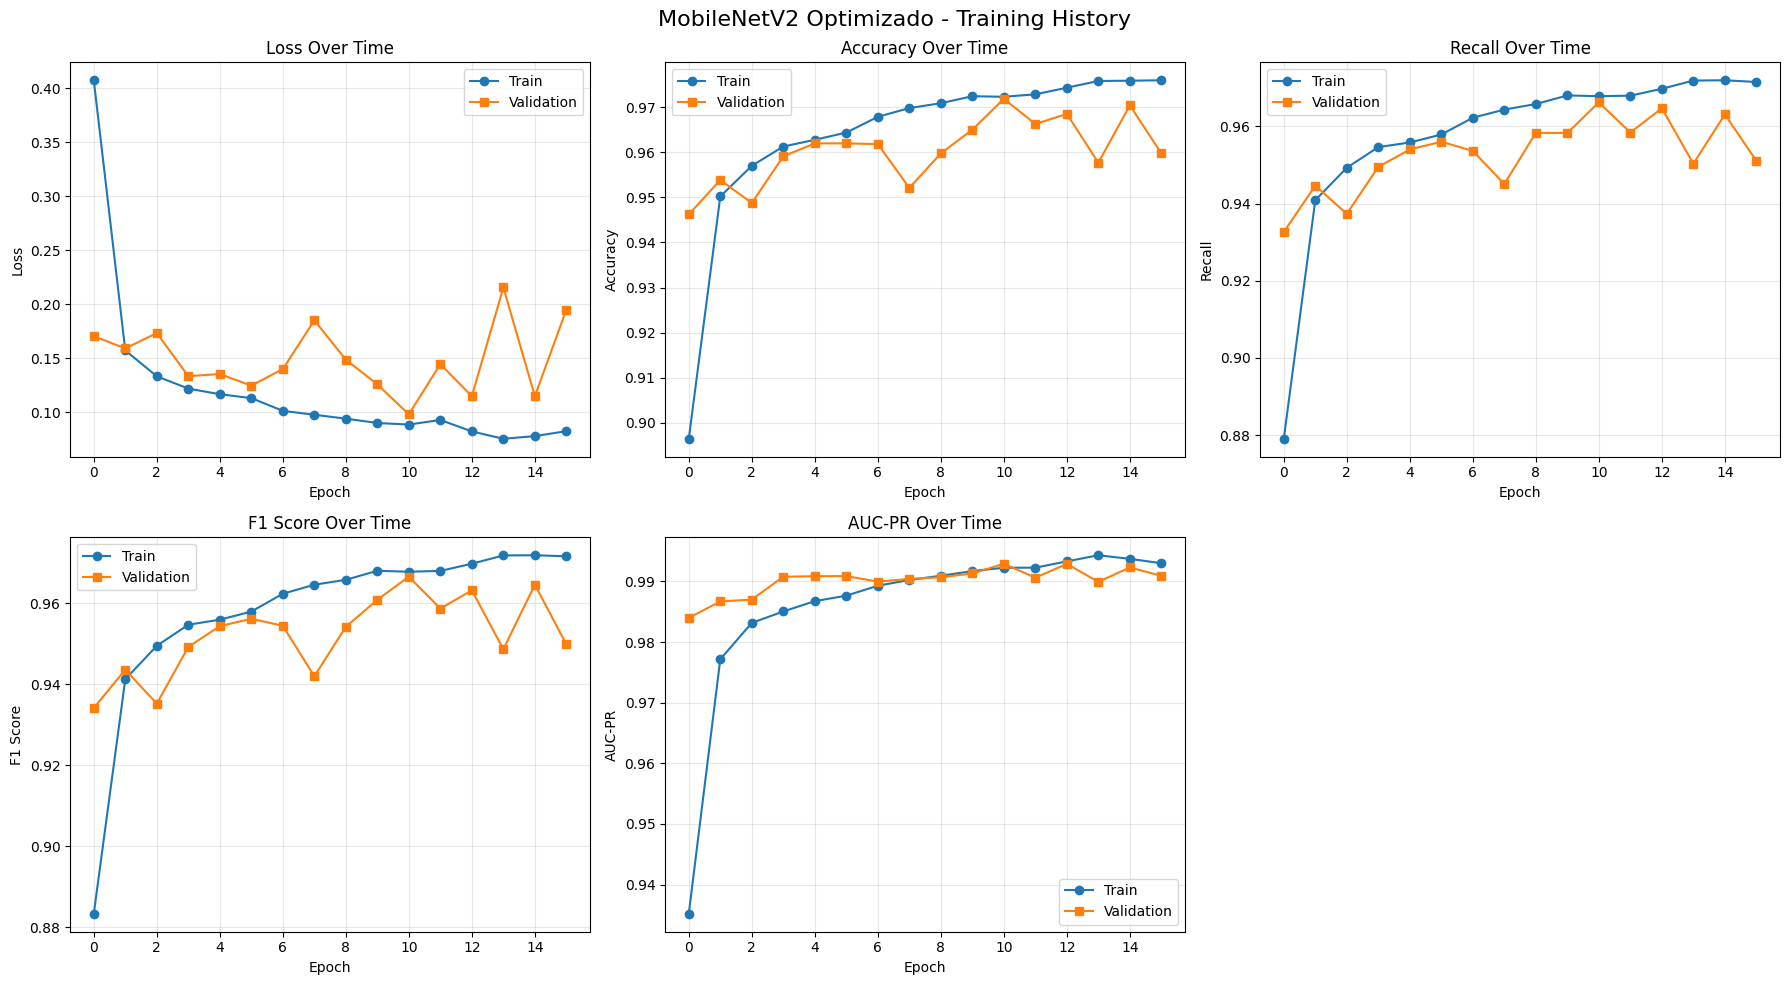

In [28]:
print("="*70)
print("ENTRENANDO MODELO 1: MobileNetV2 Optimizado")
print("="*70)

# Crear modelo con mejores hiperparámetros
model_v2_opt = create_model_with_custom_classifier(
    backbone_model=models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1),
    num_classes=num_classes,
    numerical_features_dim=numerical_features_dim, # Asegurarse de pasar esta variable
    hidden_dim=best_params_v2['hidden_dim'],
    num_layers=best_params_v2['num_layers'],
    dropout=best_params_v2['dropout']
)

# Configurar optimizer y criterion
criterion = nn.CrossEntropyLoss()

if best_params_v2['optimizer'] == 'SGD':
    optimizer_v2 = optim.SGD(
        model_v2_opt.custom_classifier.parameters(),
        lr=best_params_v2['lr'],
        momentum=0.9,
        weight_decay=best_params_v2['weight_decay']
    )
else:
    optimizer_v2 = optim.Adam(
        model_v2_opt.custom_classifier.parameters(),
        lr=best_params_v2['lr'],
        weight_decay=best_params_v2['weight_decay']
    )

# Entrenar
num_epochs = 50
model_v2_opt, hist_v2, time_v2 = train_model(
    model_v2_opt,
    dataloaders_v2,
    criterion,
    optimizer_v2,
    num_epochs=num_epochs,
    patience=5,
    device=device
)

# Visualizar resultados
plot_history(hist_v2, title="MobileNetV2 Optimizado - Training History")


### 8.2 Modelo 2: MobileNetV3 Small


In [29]:
optimal_batch_size = best_params_v3['batch_size']

dataloaders_v3 = {
    'train': DataLoader(train_dataset, batch_size=optimal_batch_size, shuffle=True,
                    num_workers=5, prefetch_factor=2, pin_memory=True,
                    persistent_workers=True, pin_memory_device="cuda"),
    'val': DataLoader(val_dataset, batch_size=optimal_batch_size, shuffle=False,
                     num_workers=5, prefetch_factor=2, pin_memory=True,
                  persistent_workers=True, pin_memory_device="cuda"),
    'test': DataLoader(test_dataset, batch_size=optimal_batch_size, shuffle=False,
                  num_workers=5, prefetch_factor=2, pin_memory=True,
                  persistent_workers=True, pin_memory_device="cuda")
}

print(f"✅ Dataloaders creados con batch_size={optimal_batch_size}")
print(f"   Train: {len(dataloaders_v3['train'])} imágenes (100% del dataset)")
print(f"   Val: {len(dataloaders_v3['val'])} imágenes (100% del dataset)")
print(f"   Test: {len(dataloaders_v3['test'])} imágenes (100% del dataset)")


✅ Dataloaders creados con batch_size=128
   Train: 394 imágenes (100% del dataset)
   Val: 50 imágenes (100% del dataset)
   Test: 50 imágenes (100% del dataset)



ENTRENANDO MODELO 2: MobileNetV3 Small
Epoch 1/50
----------
train Loss: 0.6779 Acc: 0.8402 Recall: 0.8147 F1: 0.8194 AUC-PR: 0.8787
val Loss: 0.3122 Acc: 0.9064 Recall: 0.8821 F1: 0.8812 AUC-PR: 0.9728
Epoch 2/50
----------
train Loss: 0.2234 Acc: 0.9329 Recall: 0.9205 F1: 0.9211 AUC-PR: 0.9631
val Loss: 0.1818 Acc: 0.9400 Recall: 0.9323 F1: 0.9319 AUC-PR: 0.9824
Epoch 3/50
----------
train Loss: 0.1783 Acc: 0.9432 Recall: 0.9331 F1: 0.9333 AUC-PR: 0.9729
val Loss: 0.2168 Acc: 0.9377 Recall: 0.9219 F1: 0.9207 AUC-PR: 0.9833
Epoch 4/50
----------
train Loss: 0.1679 Acc: 0.9469 Recall: 0.9376 F1: 0.9377 AUC-PR: 0.9756
val Loss: 0.1510 Acc: 0.9510 Recall: 0.9416 F1: 0.9425 AUC-PR: 0.9875
Epoch 5/50
----------
train Loss: 0.1449 Acc: 0.9527 Recall: 0.9445 F1: 0.9447 AUC-PR: 0.9797
val Loss: 0.2137 Acc: 0.9377 Recall: 0.9273 F1: 0.9228 AUC-PR: 0.9841
Epoch 6/50
----------
train Loss: 0.1336 Acc: 0.9565 Recall: 0.9494 F1: 0.9494 AUC-PR: 0.9824
val Loss: 0.2128 Acc: 0.9314 Recall: 0.9174 F1

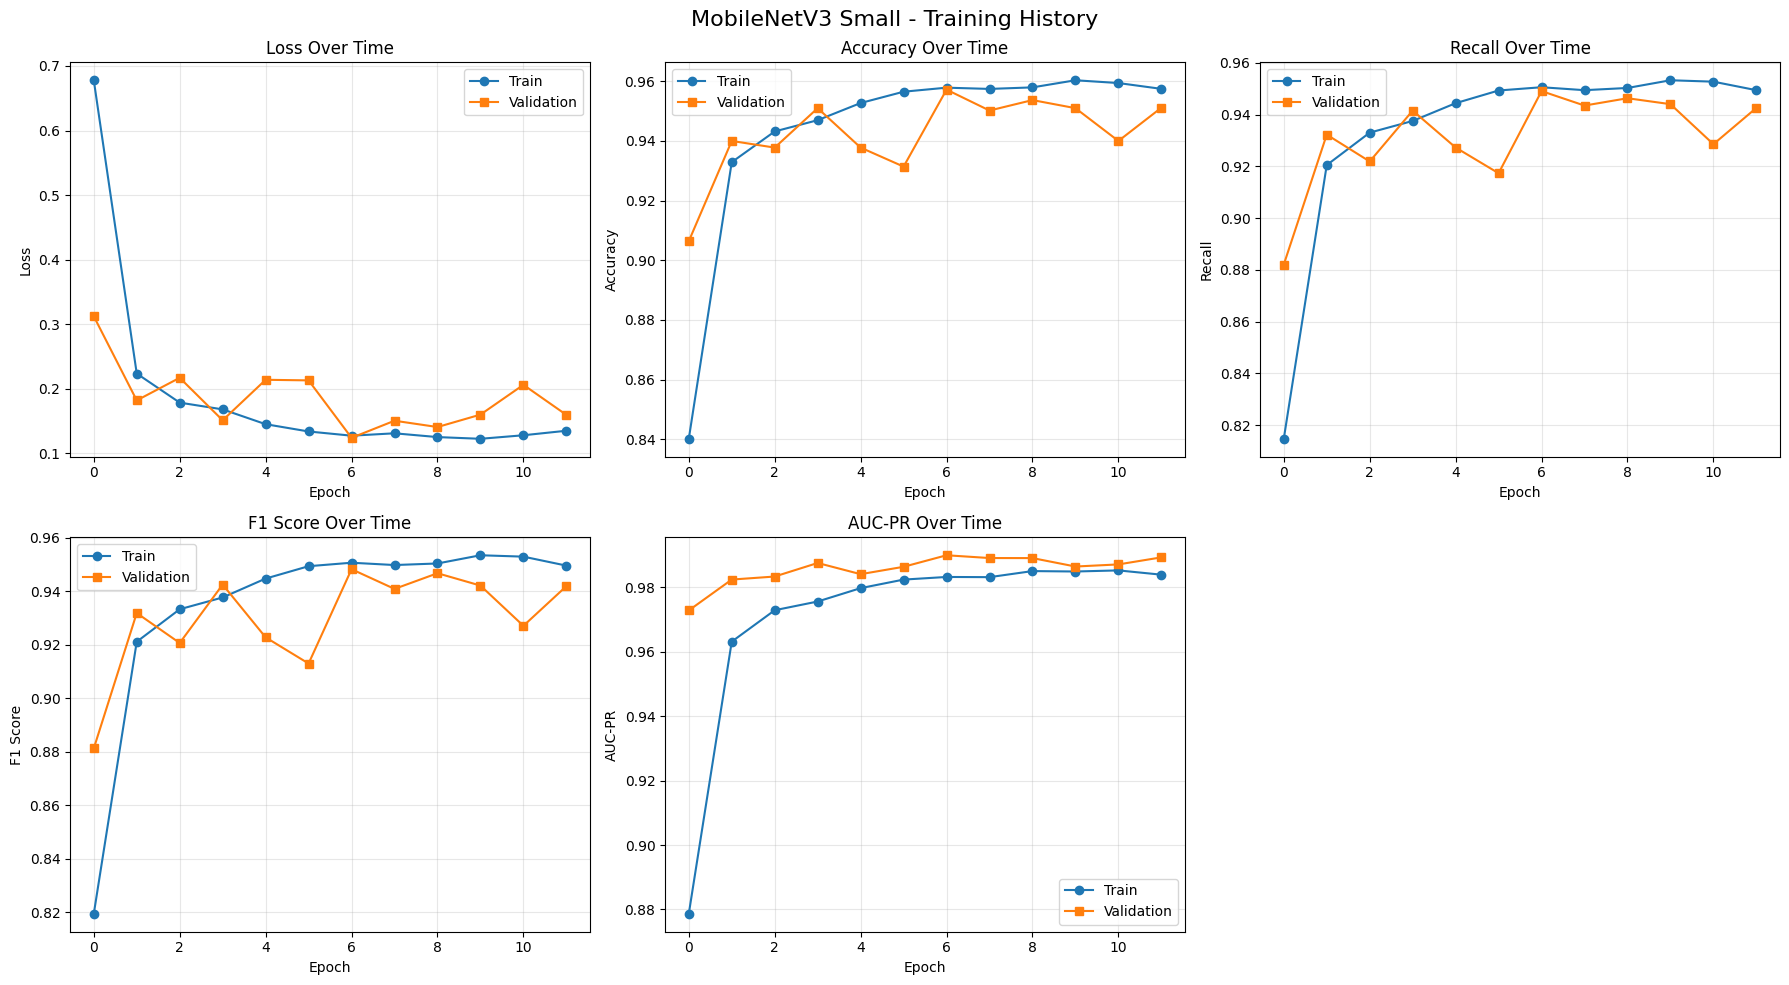

In [30]:
print("\n" + "="*70)
print("ENTRENANDO MODELO 2: MobileNetV3 Small")
print("="*70)

# Crear modelo con mejores hiperparámetros
model_v3_opt = create_model_with_custom_classifier(
    backbone_model=models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1),
    num_classes=num_classes,
    numerical_features_dim=numerical_features_dim,
    hidden_dim=best_params_v3['hidden_dim'],
    num_layers=best_params_v3['num_layers'],
    dropout=best_params_v3['dropout']
)

# Configurar optimizer y criterion
criterion = nn.CrossEntropyLoss()

if best_params_v3['optimizer'] == 'SGD':
    optimizer_v3 = optim.SGD(
        model_v3_opt.custom_classifier.parameters(),
        lr=best_params_v3['lr'],
        momentum=0.9,
        weight_decay=best_params_v3['weight_decay']
    )
else:
    optimizer_v3 = optim.Adam(
        model_v3_opt.custom_classifier.parameters(),
        lr=best_params_v3['lr'],
        weight_decay=best_params_v3['weight_decay']
    )

# Entrenar
num_epochs = 50
model_v3_opt, hist_v3, time_v3 = train_model(
    model_v3_opt,
    dataloaders_v3,
    criterion,
    optimizer_v3,
    num_epochs=num_epochs,
    patience=5,
    device=device
)

# Visualizar resultados
plot_history(hist_v3, title="MobileNetV3 Small - Training History")

## 9. Evaluación y Comparación de Modelos


In [31]:
print("="*70)
print("EVALUACIÓN DE MODELOS EN TEST SET")
print("="*70)

# Evaluar todos los modelos en CPU para comparación justa
print("\nEvaluando MobileNetV2...")
acc_v2, recall_v2, f1_v2, auc_pr_v2, inf_time_v2 = evaluate_model(model_v2_opt, dataloaders_v2['test'], 'cpu')
size_v2 = get_model_size(model_v2_opt, "v2_opt_temp")

print("\nEvaluando MobileNetV3...")
acc_v3, recall_v3, f1_v3, auc_pr_v3, inf_time_v3 = evaluate_model(model_v3_opt, dataloaders_v3['test'], 'cpu')
size_v3 = get_model_size(model_v3_opt, "v3_temp")

# Crear tabla de resultados
results = {
    'MobileNetV2': {
        'Accuracy': acc_v2,
        'Recall': recall_v2,
        'F1 Score': f1_v2,
        'AUC-PR': auc_pr_v2,
        'Size (MB)': size_v2,
        'Inference Time (s)': inf_time_v2
    },
    'MobileNetV3': {
        'Accuracy': acc_v3,
        'Recall': recall_v3,
        'F1 Score': f1_v3,
        'AUC-PR': auc_pr_v3,
        'Size (MB)': size_v3,
        'Inference Time (s)': inf_time_v3
    }
}

df_results = pd.DataFrame(results).T

print("\n" + "="*70)
print("RESUMEN DE RESULTADOS")
print("="*70)
print(df_results.to_string())
print("="*70)


EVALUACIÓN DE MODELOS EN TEST SET

Evaluando MobileNetV2...

Evaluando MobileNetV3...

RESUMEN DE RESULTADOS
             Accuracy    Recall  F1 Score    AUC-PR  Size (MB)  Inference Time (s)
MobileNetV2  0.968849  0.960973  0.962889  0.991662  14.462671          110.304133
MobileNetV3  0.958571  0.951846  0.951295  0.989822  10.395283           24.875899


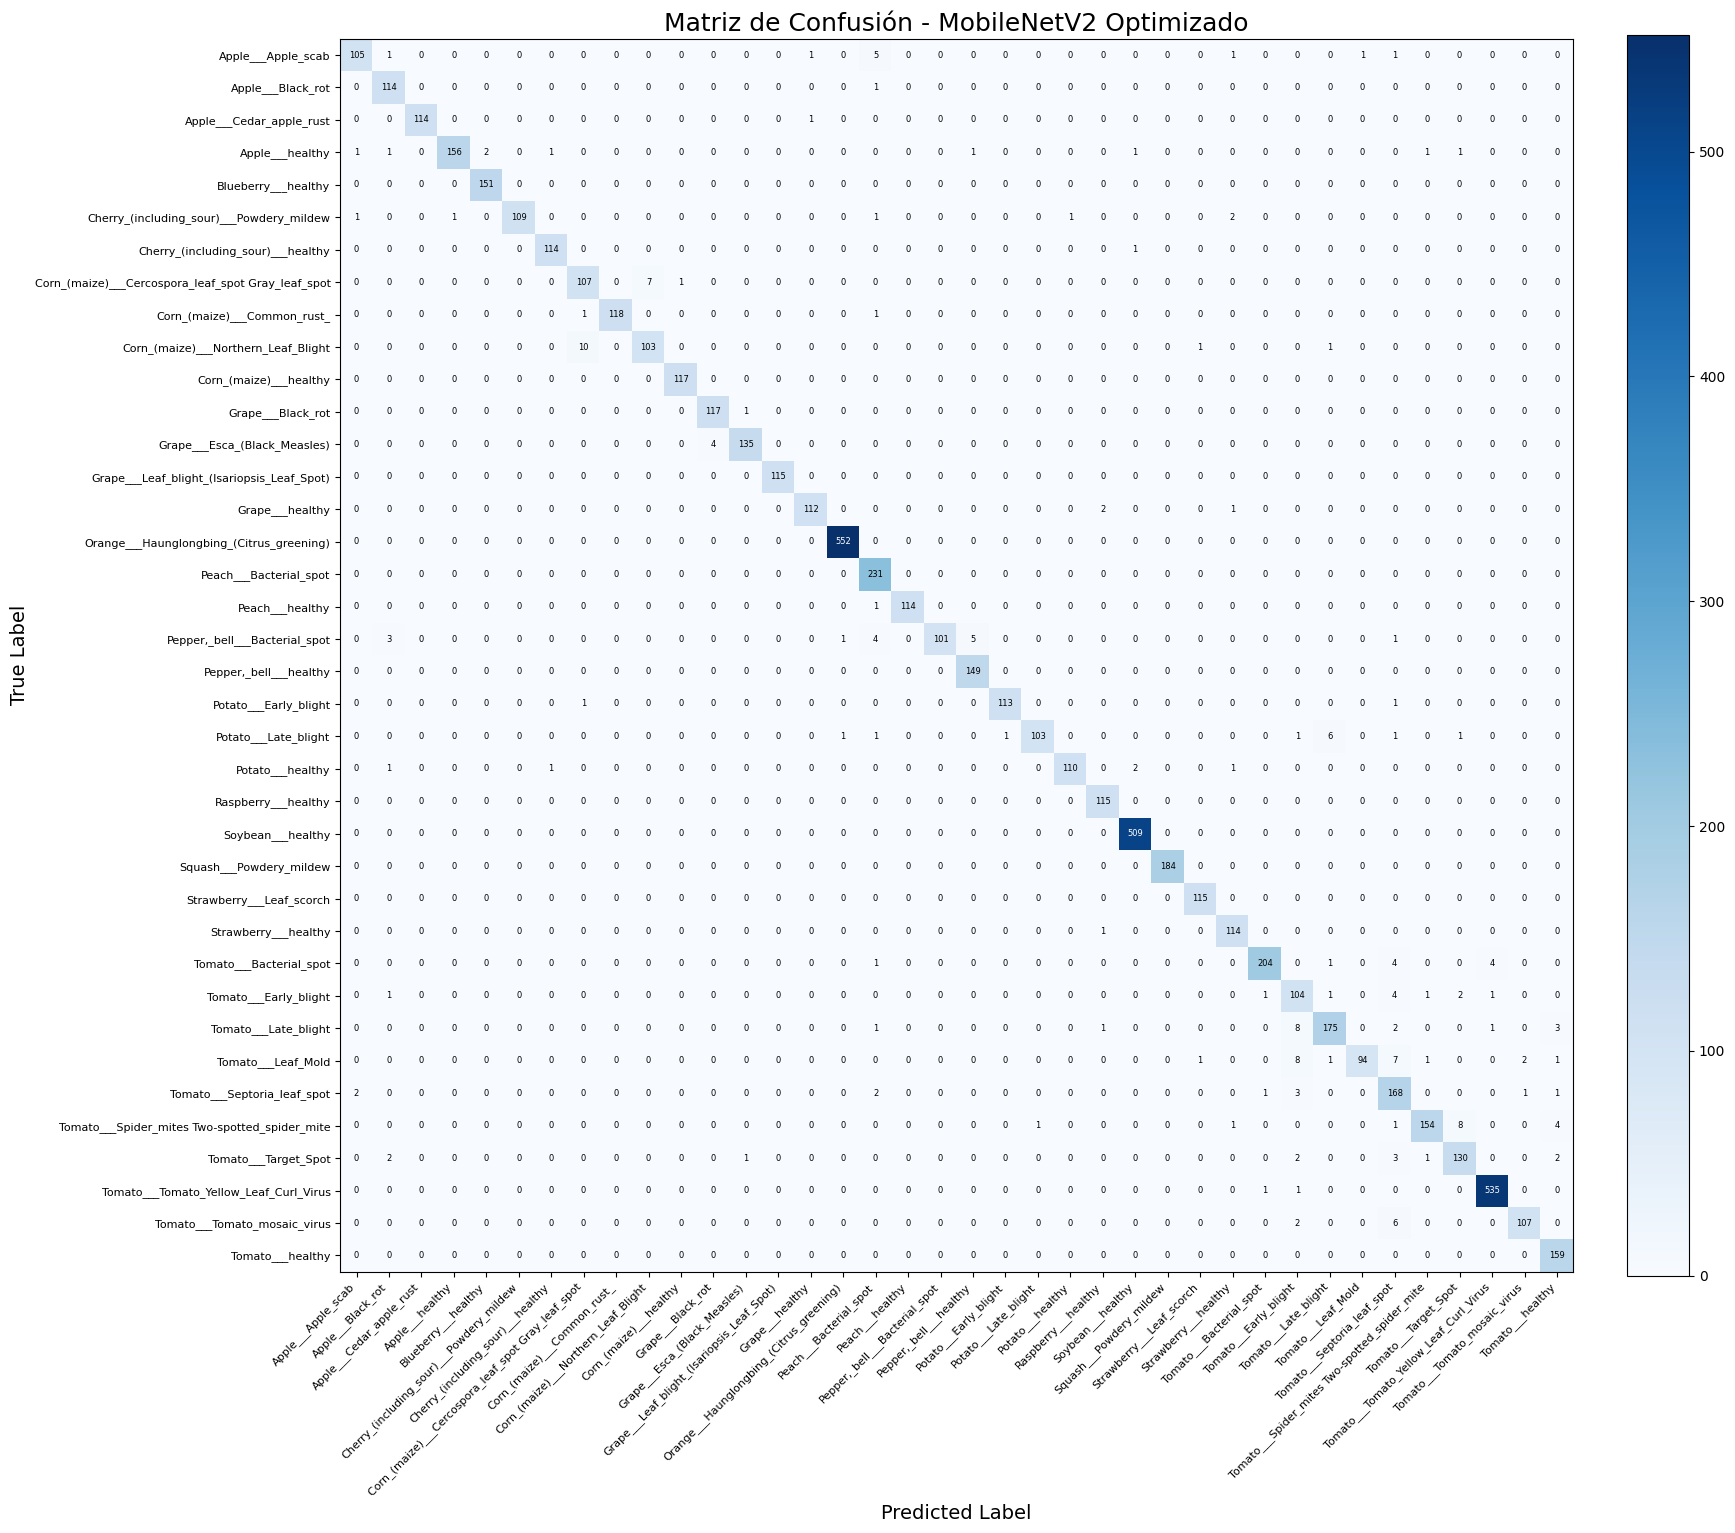

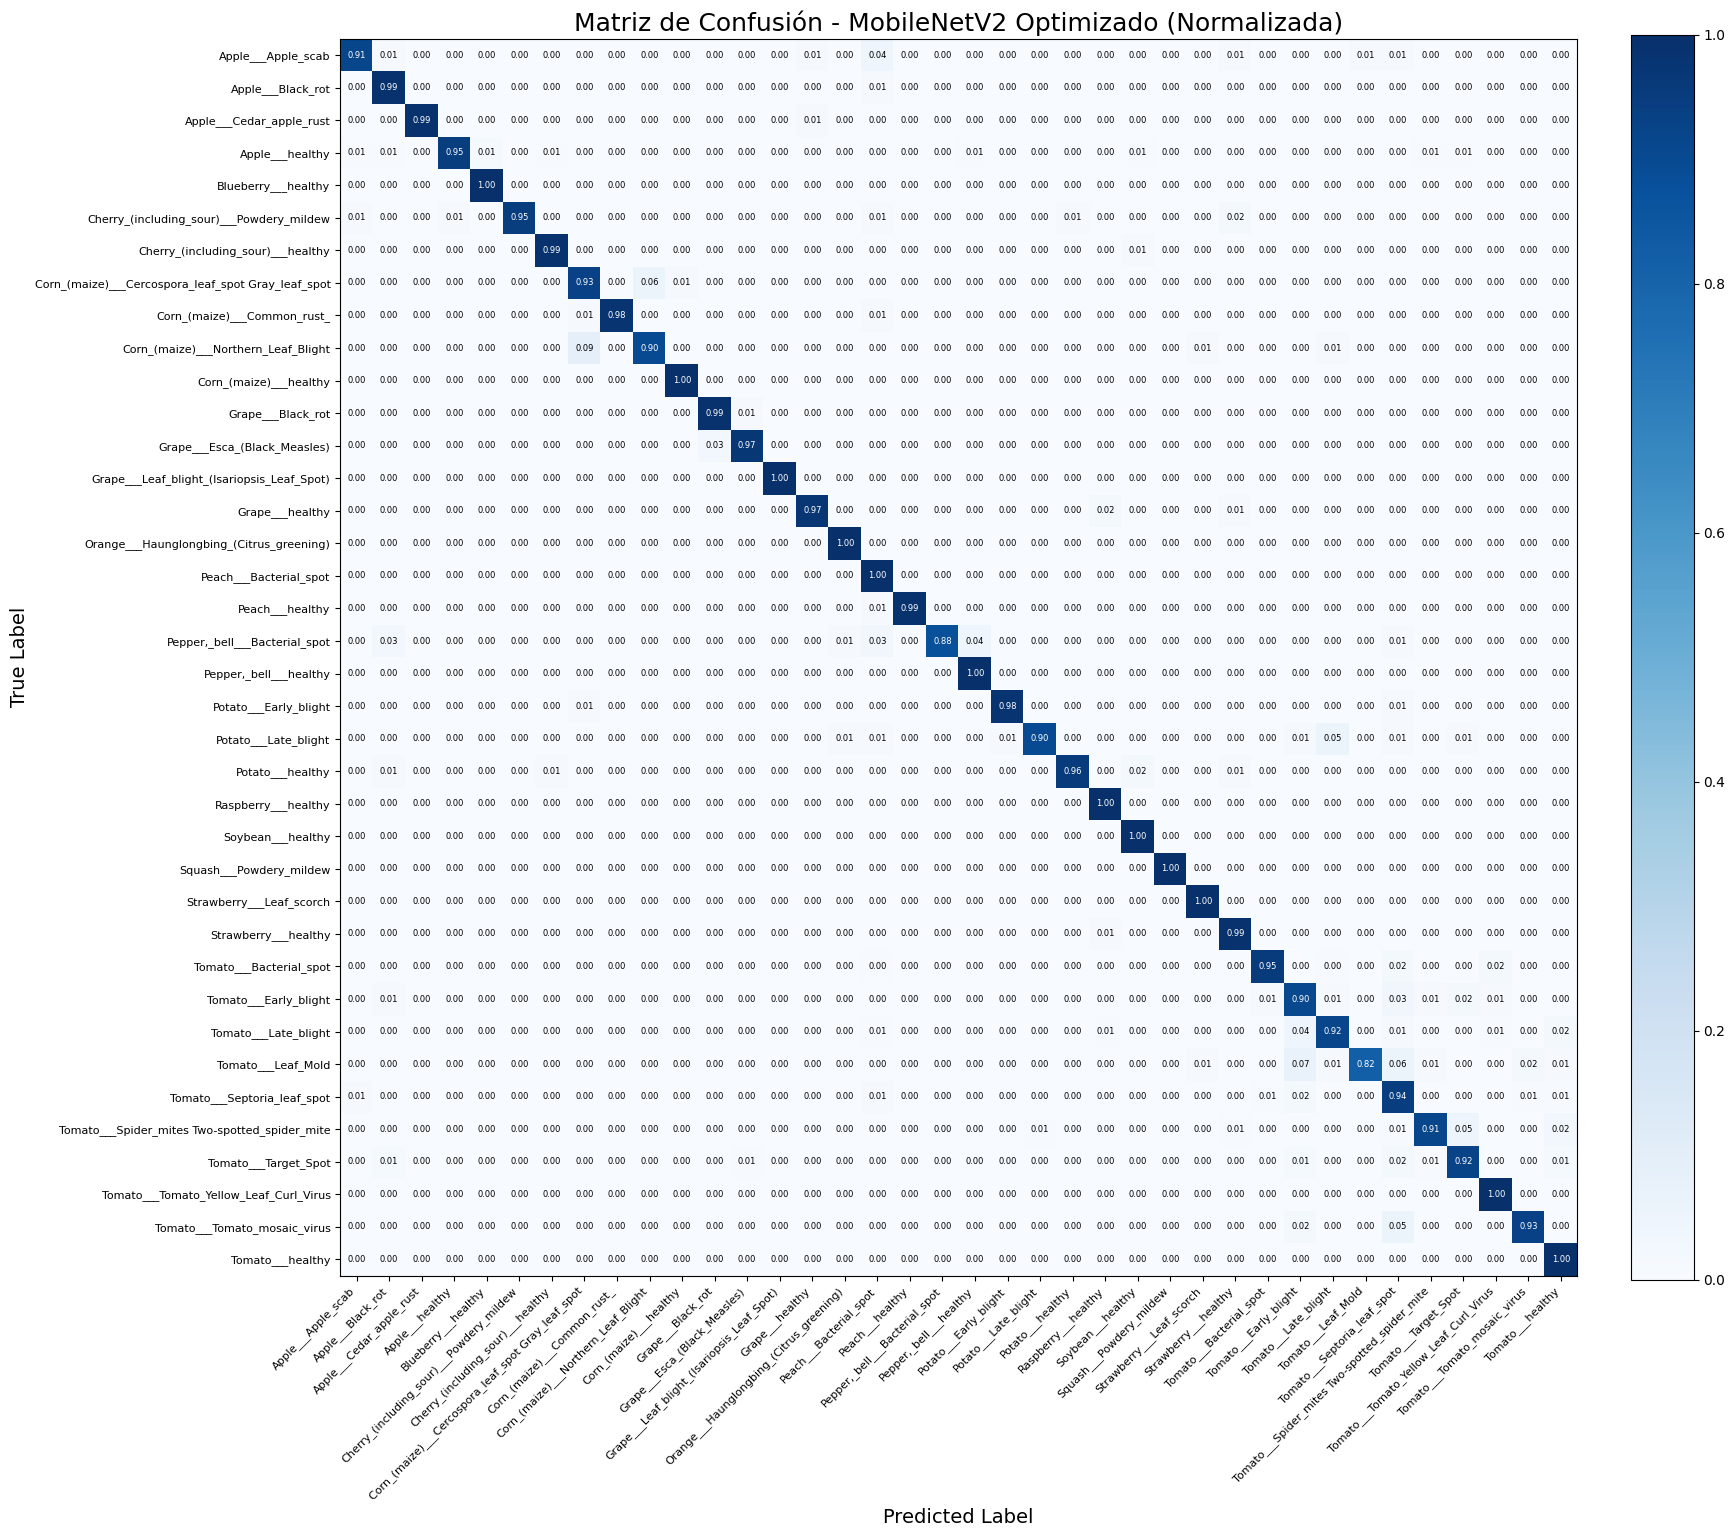

Overall Accuracy MobileNetV2: 0.9688
Recall Macro MobileNetV2: 0.9610

Classification Report MobileNetV2:

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.96      0.91      0.94       115
                                 Apple___Black_rot       0.93      0.99      0.96       115
                          Apple___Cedar_apple_rust       1.00      0.99      1.00       115
                                   Apple___healthy       0.99      0.95      0.97       165
                               Blueberry___healthy       0.99      1.00      0.99       151
          Cherry_(including_sour)___Powdery_mildew       1.00      0.95      0.97       115
                 Cherry_(including_sour)___healthy       0.98      0.99      0.99       115
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.90      0.93      0.91       115
                       Corn_(maize)___Common_rust_       1.00   

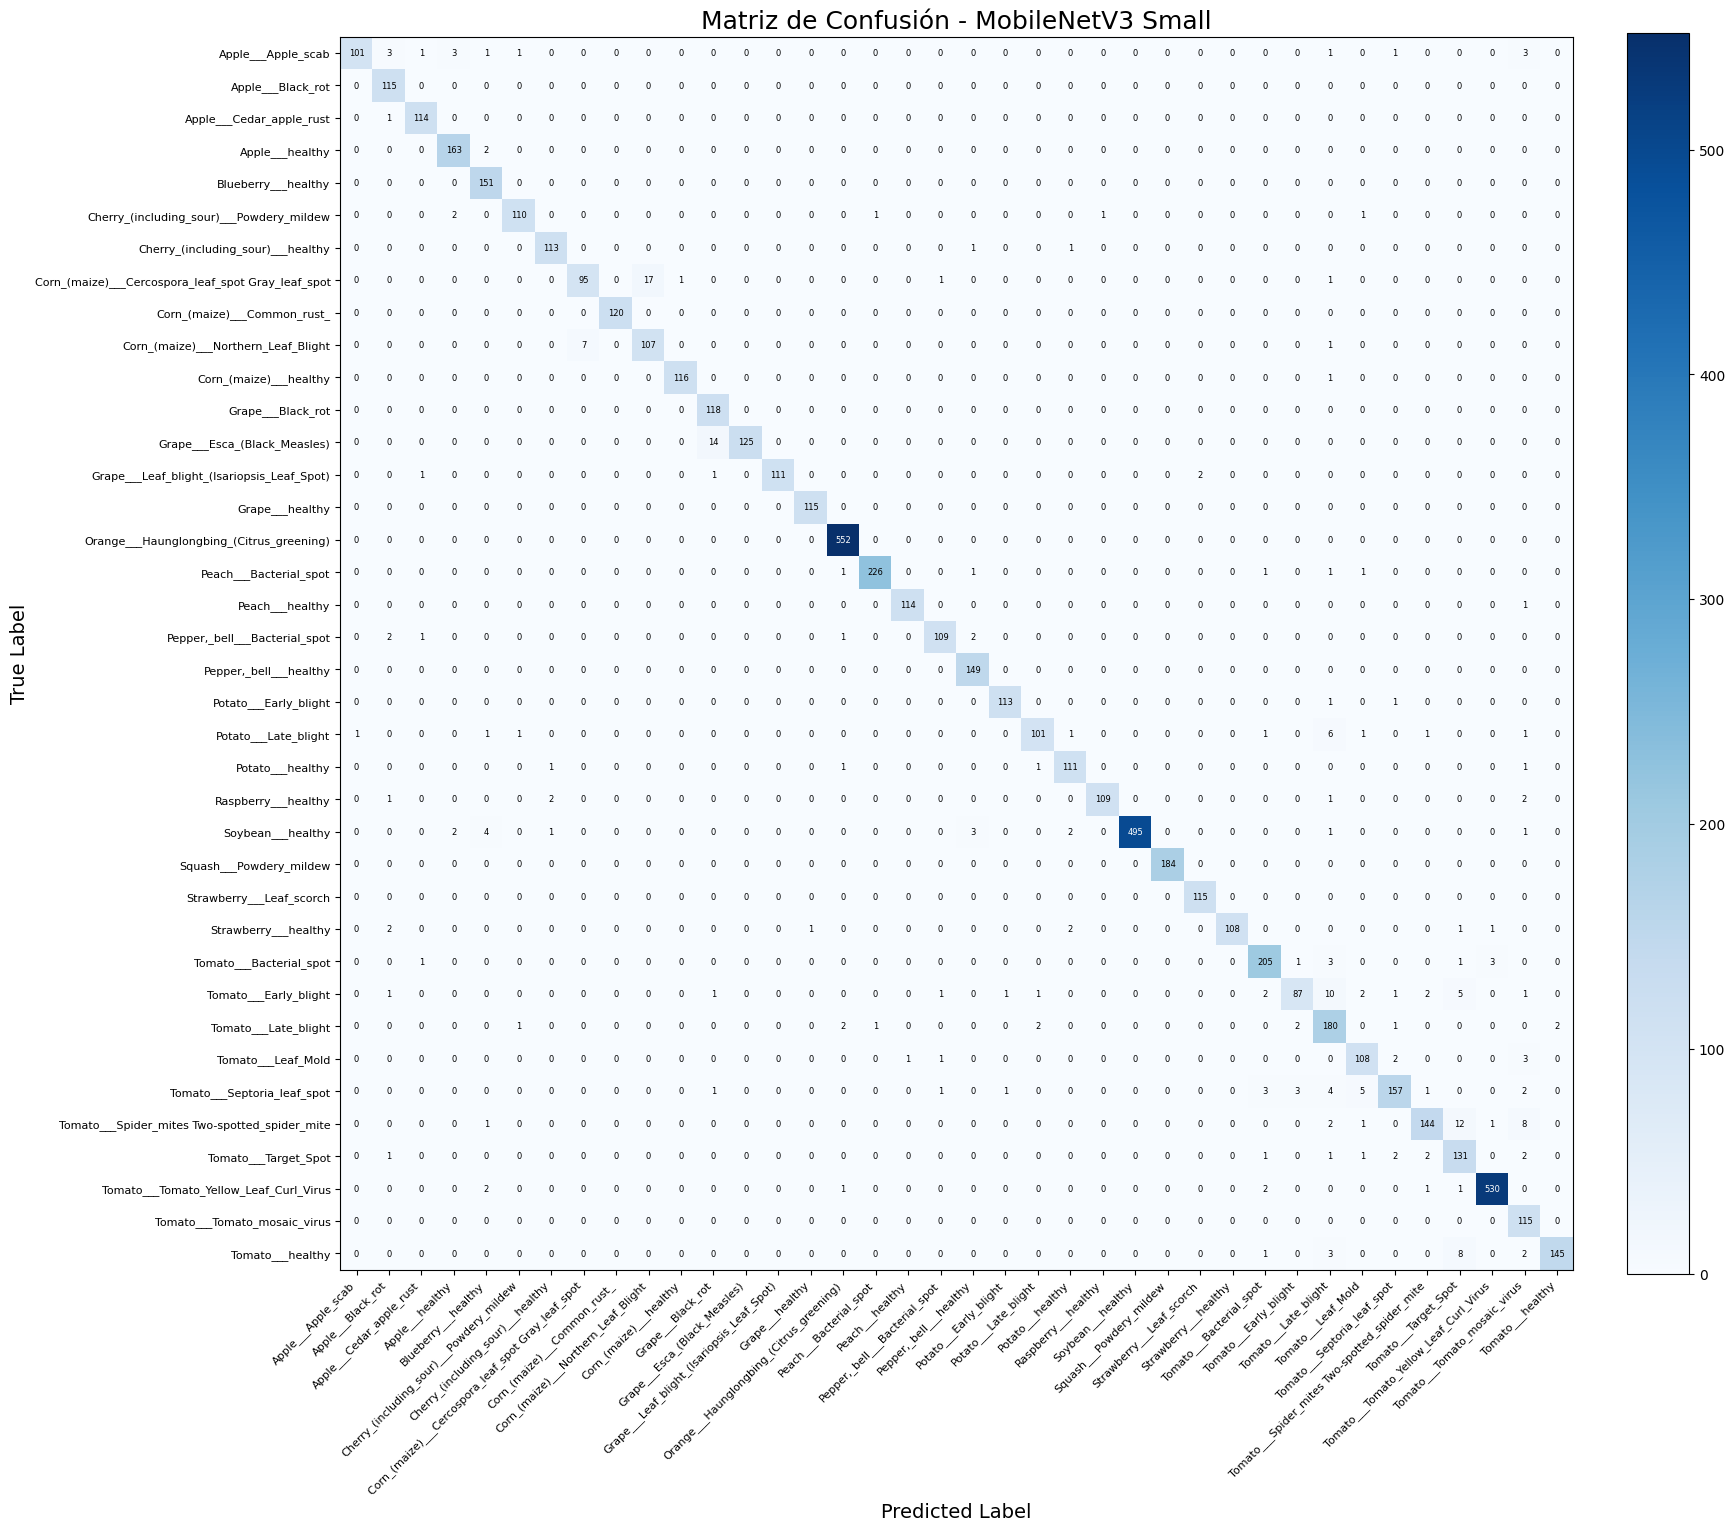

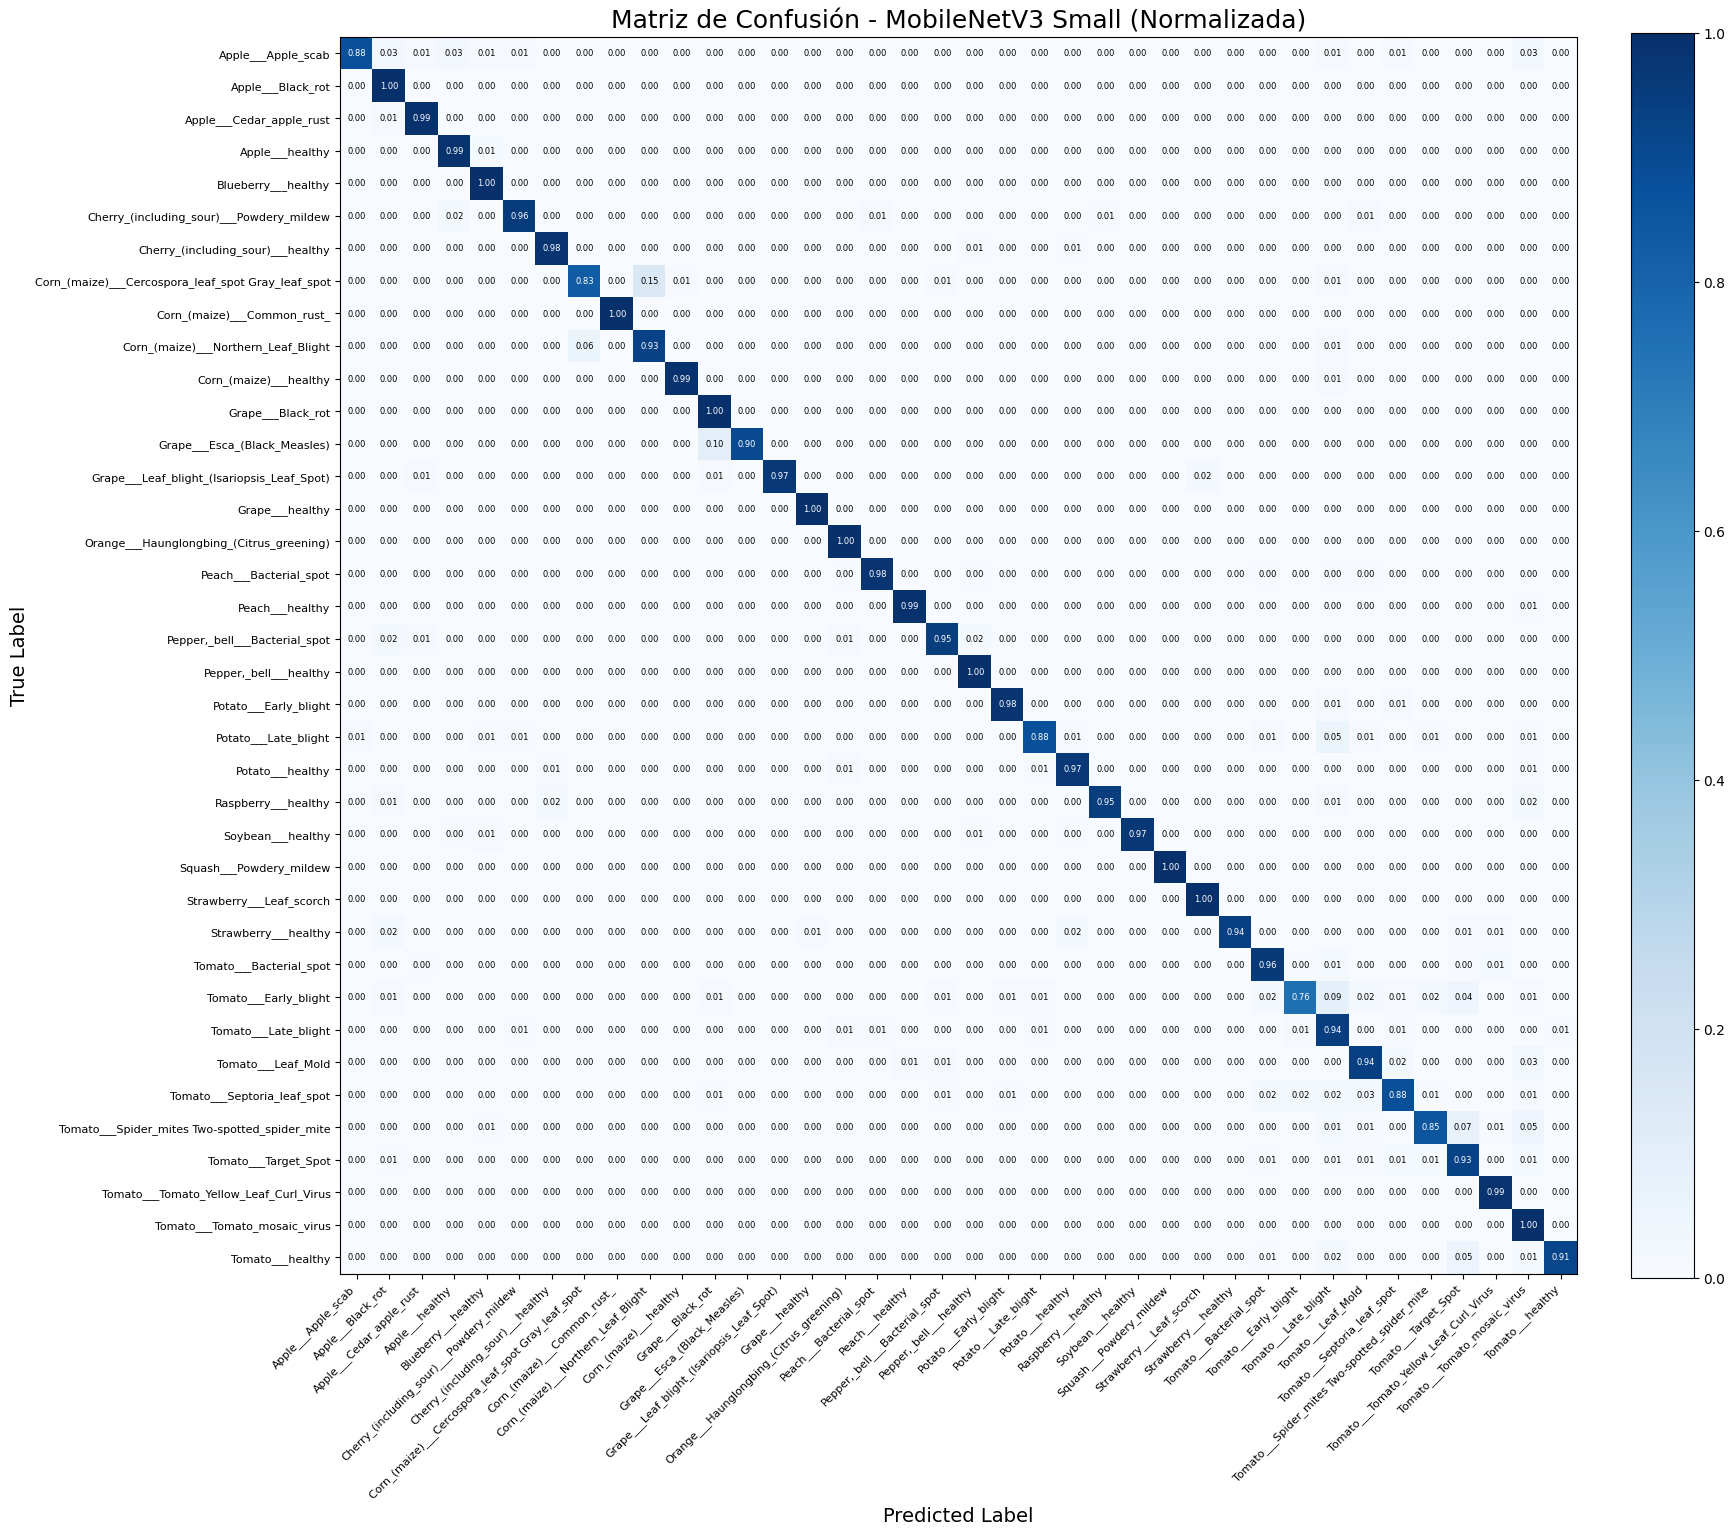

Overall Accuracy MobileNetV3: 0.9586
Recall Macro MobileNetV3: 0.9518

Classification Report MobileNetV3:

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.99      0.88      0.93       115
                                 Apple___Black_rot       0.91      1.00      0.95       115
                          Apple___Cedar_apple_rust       0.97      0.99      0.98       115
                                   Apple___healthy       0.96      0.99      0.97       165
                               Blueberry___healthy       0.93      1.00      0.96       151
          Cherry_(including_sour)___Powdery_mildew       0.97      0.96      0.96       115
                 Cherry_(including_sour)___healthy       0.97      0.98      0.97       115
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.93      0.83      0.88       115
                       Corn_(maize)___Common_rust_       1.00   

In [32]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, recall_score

# --- Función para crear matriz de confusión y retornar predicciones y etiquetas ---
def create_confusion_matrix(model, dataloader, device='cpu'):
    all_preds = []
    all_labels = []

    model.eval()
    with torch.no_grad():
        for images, numerical_features, labels in dataloader:
            images = images.to(device)
            numerical_features = numerical_features.to(device)
            labels = labels.to(device)

            outputs = model(images, numerical_features)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    return cm, all_labels, all_preds

# --- Función para graficar matriz de confusión ---
def plot_cm(cm, classes, title, cmap=plt.cm.Blues, normalize=False):
    if normalize:
        cm_to_plot = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        fmt = '.2f'
        title += " (Normalizada)"
    else:
        cm_to_plot = cm
        fmt = 'd'

    plt.figure(figsize=(20, 20))
    plt.imshow(cm_to_plot, interpolation='nearest', cmap=cmap)
    plt.title(title, fontsize=18)
    plt.colorbar(fraction=0.046, pad=0.04)

    thresh = cm_to_plot.max() / 2.
    for i in range(cm_to_plot.shape[0]):
        for j in range(cm_to_plot.shape[1]):
            plt.text(j, i, format(cm_to_plot[i, j], fmt),
                     horizontalalignment="center",
                     verticalalignment="center",
                     fontsize=6,
                     color="white" if cm_to_plot[i, j] > thresh else "black")

    plt.ylabel('True Label', fontsize=14)
    plt.xlabel('Predicted Label', fontsize=14)
    plt.xticks(ticks=np.arange(len(classes)), labels=classes, rotation=45, ha='right', fontsize=8)
    plt.yticks(ticks=np.arange(len(classes)), labels=classes, fontsize=8)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.3, left=0.3)
    plt.show()


# ------------------- MobileNetV2 -------------------
cm_v2, all_labels_v2, all_preds_v2 = create_confusion_matrix(model_v2_opt, dataloaders_v2['test'], device='cpu')

# Graficar matriz de confusión
plot_cm(cm_v2, train_dataset.classes, "Matriz de Confusión - MobileNetV2 Optimizado")
plot_cm(cm_v2, train_dataset.classes, "Matriz de Confusión - MobileNetV2 Optimizado", normalize=True)

# Métricas y reporte
overall_acc_v2 = accuracy_score(all_labels_v2, all_preds_v2)
recall_macro_v2 = recall_score(all_labels_v2, all_preds_v2, average='macro', zero_division=0)
report_v2 = classification_report(all_labels_v2, all_preds_v2, target_names=train_dataset.classes, zero_division=0)

print(f"Overall Accuracy MobileNetV2: {overall_acc_v2:.4f}")
print(f"Recall Macro MobileNetV2: {recall_macro_v2:.4f}\n")
print("Classification Report MobileNetV2:\n")
print(report_v2)


# ------------------- MobileNetV3 -------------------
cm_v3, all_labels_v3, all_preds_v3 = create_confusion_matrix(model_v3_opt, dataloaders_v3['test'], device='cpu')

# Graficar matriz de confusión
plot_cm(cm_v3, train_dataset.classes, "Matriz de Confusión - MobileNetV3 Small")
plot_cm(cm_v3, train_dataset.classes, "Matriz de Confusión - MobileNetV3 Small", normalize=True)

# Métricas y reporte
overall_acc_v3 = accuracy_score(all_labels_v3, all_preds_v3)
recall_macro_v3 = recall_score(all_labels_v3, all_preds_v3, average='macro', zero_division=0)
report_v3 = classification_report(all_labels_v3, all_preds_v3, target_names=train_dataset.classes, zero_division=0)

print(f"Overall Accuracy MobileNetV3: {overall_acc_v3:.4f}")
print(f"Recall Macro MobileNetV3: {recall_macro_v3:.4f}\n")
print("Classification Report MobileNetV3:\n")
print(report_v3)

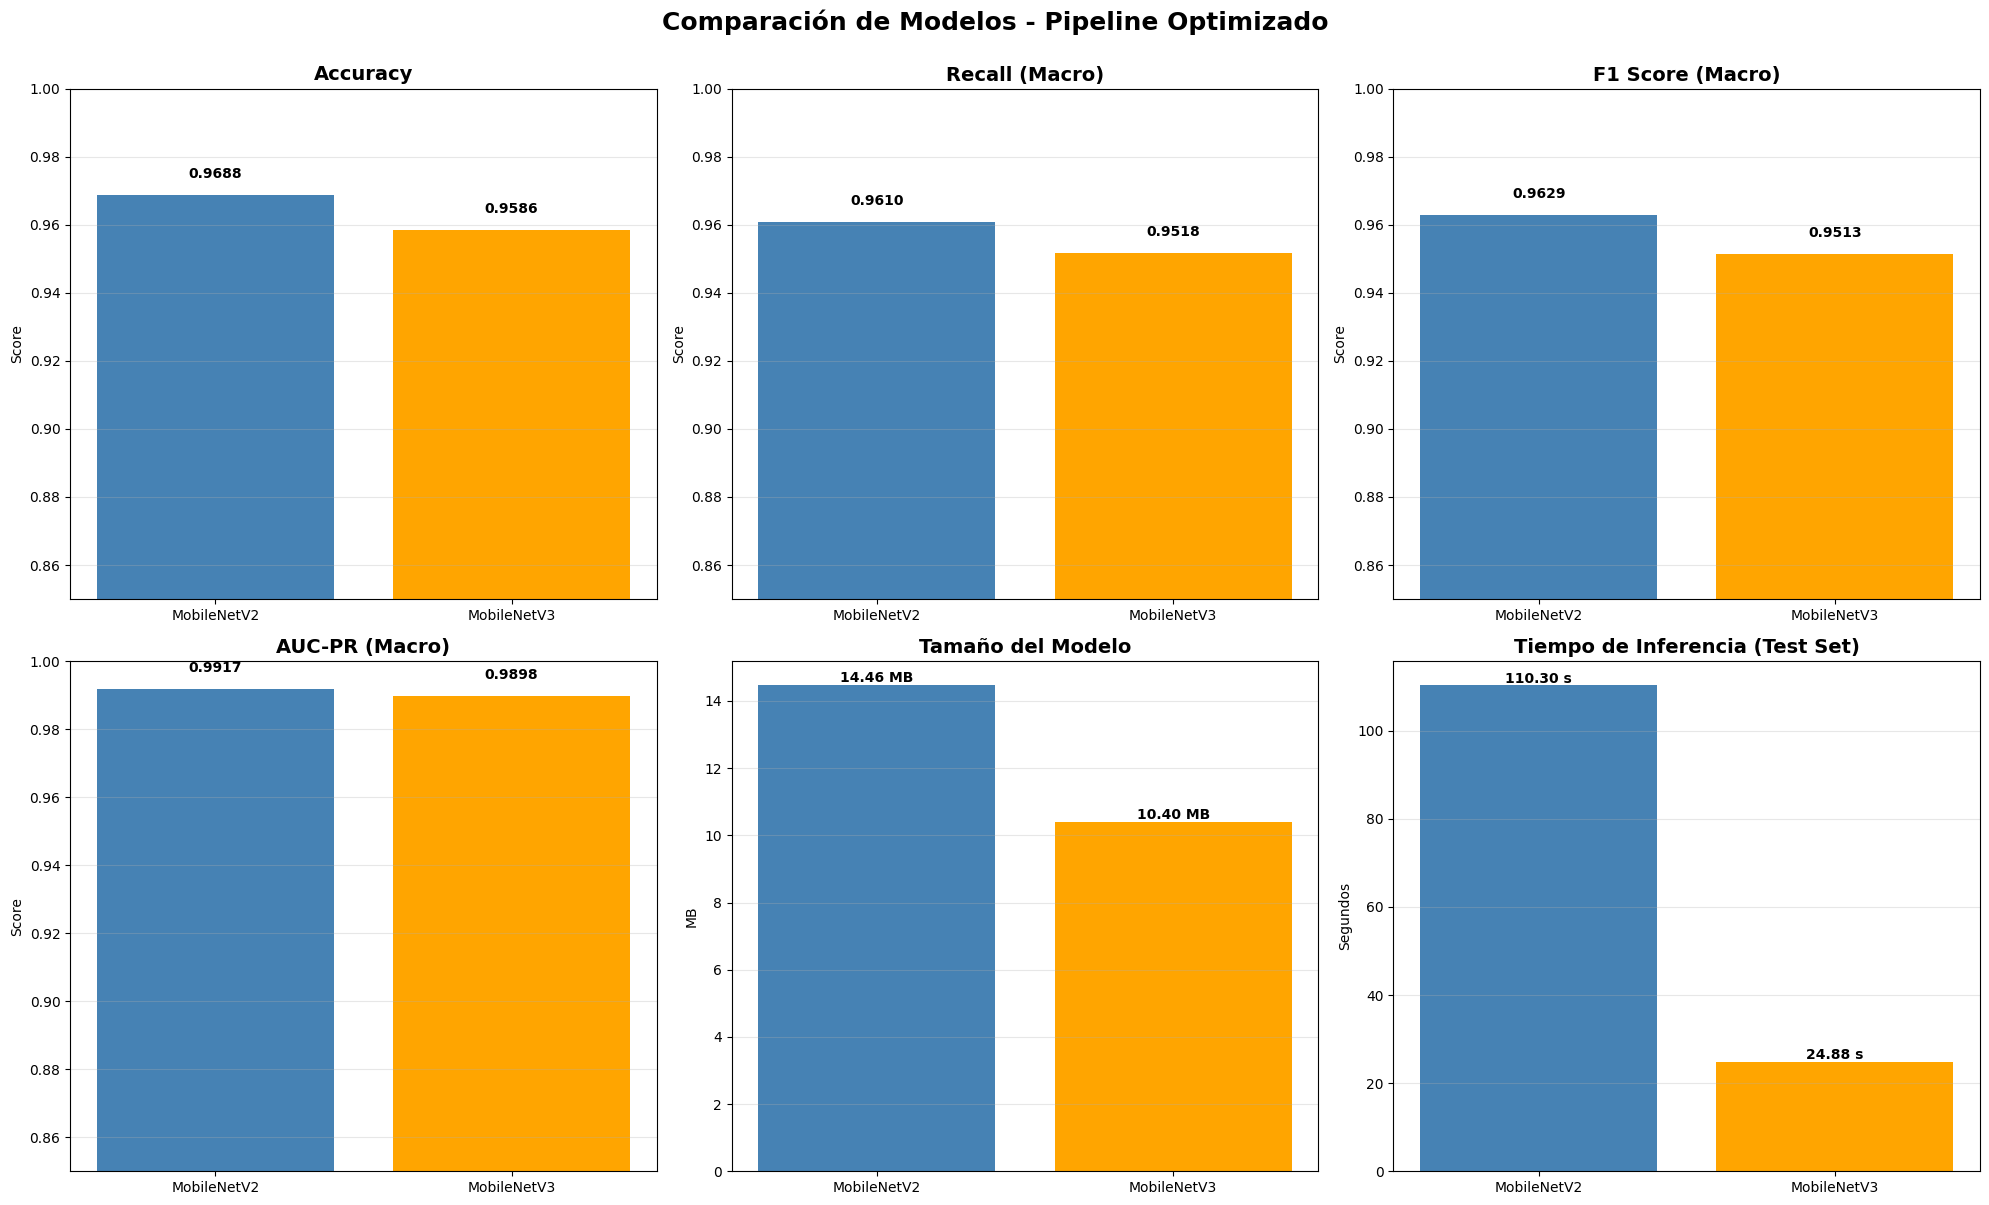

In [33]:
# Visualización comparativa
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

models_list = df_results.index.tolist()
colors = ['steelblue', 'orange', 'forestgreen']

# 1. Accuracy
axes[0, 0].bar(models_list, df_results['Accuracy'], color=colors)
axes[0, 0].set_title('Accuracy', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Score')
axes[0, 0].set_ylim(0.85, 1.0)
axes[0, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_results['Accuracy']):
    axes[0, 0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

# 2. Recall
axes[0, 1].bar(models_list, df_results['Recall'], color=colors)
axes[0, 1].set_title('Recall (Macro)', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Score')
axes[0, 1].set_ylim(0.85, 1.0)
axes[0, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_results['Recall']):
    axes[0, 1].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

# 3. F1 Score
axes[0, 2].bar(models_list, df_results['F1 Score'], color=colors)
axes[0, 2].set_title('F1 Score (Macro)', fontsize=14, fontweight='bold')
axes[0, 2].set_ylabel('Score')
axes[0, 2].set_ylim(0.85, 1.0)
axes[0, 2].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_results['F1 Score']):
    axes[0, 2].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

# 4. AUC-PR
axes[1, 0].bar(models_list, df_results['AUC-PR'], color=colors)
axes[1, 0].set_title('AUC-PR (Macro)', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Score')
axes[1, 0].set_ylim(0.85, 1.0)
axes[1, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_results['AUC-PR']):
    axes[1, 0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

# 5. Tamaño del modelo
axes[1, 1].bar(models_list, df_results['Size (MB)'], color=colors)
axes[1, 1].set_title('Tamaño del Modelo', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('MB')
axes[1, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_results['Size (MB)']):
    axes[1, 1].text(i, v + 0.1, f'{v:.2f} MB', ha='center', fontweight='bold')

# 6. Tiempo de inferencia
axes[1, 2].bar(models_list, df_results['Inference Time (s)'], color=colors)
axes[1, 2].set_title('Tiempo de Inferencia (Test Set)', fontsize=14, fontweight='bold')
axes[1, 2].set_ylabel('Segundos')
axes[1, 2].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_results['Inference Time (s)']):
    axes[1, 2].text(i, v + 0.5, f'{v:.2f} s', ha='center', fontweight='bold')

plt.suptitle('Comparación de Modelos - Pipeline Optimizado',
             fontsize=18, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()


## 10. Análisis de Mejoras

Comparamos el impacto de nuestras optimizaciones:


In [34]:
print("="*70)
print("ANÁLISIS DE MEJORAS IMPLEMENTADAS")
print("="*70)

print("\n1️⃣ ELIMINACIÓN DE DUPLICADOS")
print(f"   • Imágenes duplicadas eliminadas: {removed if duplicates else 0}")
print(f"   • Beneficio: Reduce overfitting y mejora generalización")

print("\n2️⃣ DATA AUGMENTATION SELECTIVO")
print(f"   • Imágenes sintéticas generadas: {generated_images}")
print(f"   • Clases balanceadas: {len(underrepresented_classes)}")
print(f"   • Beneficio: Mejora rendimiento en clases minoritarias")

print("\n3️⃣ OPTIMIZACIÓN DE HIPERPARÁMETROS (OPTUNA)")

optuna_results = {
    "MobileNetV2": {"study": study_v2, "best_params": best_params_v2},
    "MobileNetV3": {"study": study_v3, "best_params": best_params_v3},
}

for model_name, data in optuna_results.items():
    print(f"\n   • Resultados Optuna para {model_name}:")
    print(f"     - Trials ejecutados: {len(data['study'].trials)}")
    print(f"     - Mejor AUC PR encontrado: {data['study'].best_value:.4f}")
    print("     - Hiperparámetros óptimos:")
    for key, value in data['best_params'].items():
        print(f"       - {key}: {value}")
print(f"   • Beneficio: Configuración óptima automática para cada modelo")

print("\n4️⃣ RESULTADOS FINALES")
print(f"   • Mejor modelo (precisión): {df_results['Accuracy'].idxmax()}")
print(f"     - Accuracy: {df_results['Accuracy'].max():.4f}")
print(f"     - Recall: {df_results.loc[df_results['Accuracy'].idxmax(), 'Recall']:.4f}")
print(f"     - F1 Score: {df_results.loc[df_results['Accuracy'].idxmax(), 'F1 Score']:.4f}")

print(f"\n   • Mejor modelo (tamaño): {df_results['Size (MB)'].idxmin()}")
print(f"     - Tamaño: {df_results['Size (MB)'].min():.2f} MB")
print(f"     - Accuracy: {df_results.loc[df_results['Size (MB)'].idxmin(), 'Accuracy']:.4f}")

print(f"\n   • Mejor modelo (velocidad): {df_results['Inference Time (s)'].idxmin()}")
print(f"     - Tiempo: {df_results['Inference Time (s)'].min():.2f} segundos")
print(f"     - Accuracy: {df_results.loc[df_results['Inference Time (s)'].idxmin(), 'Accuracy']:.4f}")

print("\n" + "="*70)

ANÁLISIS DE MEJORAS IMPLEMENTADAS

1️⃣ ELIMINACIÓN DE DUPLICADOS
   • Imágenes duplicadas eliminadas: 21
   • Beneficio: Reduce overfitting y mejora generalización

2️⃣ DATA AUGMENTATION SELECTIVO
   • Imágenes sintéticas generadas: 8641
   • Clases balanceadas: 20
   • Beneficio: Mejora rendimiento en clases minoritarias

3️⃣ OPTIMIZACIÓN DE HIPERPARÁMETROS (OPTUNA)

   • Resultados Optuna para MobileNetV2:
     - Trials ejecutados: 30
     - Mejor AUC PR encontrado: 0.9835
     - Hiperparámetros óptimos:
       - lr: 0.0020601531857269355
       - batch_size: 64
       - hidden_dim: 512
       - num_layers: 1
       - dropout: 0.22926983808753784
       - optimizer: Adam
       - weight_decay: 1.6386558231281613e-05

   • Resultados Optuna para MobileNetV3:
     - Trials ejecutados: 30
     - Mejor AUC PR encontrado: 0.9742
     - Hiperparámetros óptimos:
       - lr: 0.00544183198601302
       - batch_size: 128
       - hidden_dim: 256
       - num_layers: 1
       - dropout: 0.3455

## 11. Conclusiones y Recomendaciones

### Resumen de Optimizaciones Implementadas

**1. Eliminación de Duplicados**
- Se detectaron y eliminaron **21 imágenes duplicadas** usando hashing MD5
- Esto reduce el sesgo de memorización y mejora la generalización del modelo
- El dataset resultante es más limpio y representativo

**2. Data Augmentation Inteligente**
- Aplicamos augmentation **solo** a las clases con representación inferior al 80% del promedio
- Se generaron **8,641 imágenes sintéticas** para balancear **20 clases** subrepresentadas
- Transformaciones aplicadas: rotación (±20°), flip horizontal/vertical, color jitter, affine transforms y recorte aleatorio
- Resultado: Dataset más balanceado sin sobre-aumentar clases ya bien representadas

**3. Integración de Features de Color**
- Se incorporaron **10 características numéricas de color** como input adicional al modelo:
  - Proporción de píxeles amarillos y verdes (detectores de enfermedad/salud)
  - Proporción de píxeles rojos y marrones (indicadores de lesiones)
  - Estadísticas RGB detalladas (media y desviación estándar por canal)
- Estas características capturan información relevante para la identificación de enfermedades en plantas

**4. Optimización de Hiperparámetros con Optuna**
- Búsqueda automática con **30 trials por modelo** usando el 30% del dataset
- Hiperparámetros optimizados: learning rate, batch size, arquitectura del clasificador, optimizer, dropout y weight decay
- **MobileNetV2**: Mejor AUC-PR en búsqueda = 0.9835
- **MobileNetV3**: Mejor AUC-PR en búsqueda = 0.9742
- Optuna utilizó Tree-structured Parzen Estimator (TPE) con pruning automático de trials no prometedores

---

### Resultados Finales en Test Set

| Modelo | Accuracy | Recall | F1 Score | AUC-PR | Tamaño | Tiempo Inferencia |
|--------|----------|--------|----------|--------|--------|-------------------|
| **MobileNetV2** | **0.9688** | **0.9610** | **0.9629** | **0.9917** | 14.46 MB | 110.30 s |
| **MobileNetV3** | 0.9586 | 0.9518 | 0.9513 | 0.9898 | **10.40 MB** | **24.88 s** |

---

### Comparación de Modelos

**MobileNetV2 Optimizado:**
- 🏆 **Mejor rendimiento general**: Accuracy 96.88%, Recall 96.10%, F1 96.29%
- 🏆 **Mayor AUC-PR** (0.9917), indicando excelente capacidad de ranking
- Hiperparámetros óptimos: lr=0.002, batch_size=64, hidden_dim=512, 1 capa, dropout=0.23, Adam
- Mayor tamaño (14.46 MB) y tiempo de inferencia más largo
- ✅ **Recomendado cuando la precisión es la máxima prioridad**

**MobileNetV3 Small:**
- Rendimiento competitivo: Accuracy 95.86%, Recall 95.18%, F1 95.13%
- 🏆 **Más compacto**: 10.40 MB (28% más pequeño que V2)
- 🏆 **Inferencia 4.4x más rápida**: 24.88s vs 110.30s
- Hiperparámetros óptimos: lr=0.005, batch_size=128, hidden_dim=256, 1 capa, dropout=0.35, Adam
- ✅ **Recomendado para deployment móvil donde velocidad y tamaño son críticos**

---

### Recomendaciones de Uso

1. **Para aplicaciones de alta precisión** (laboratorios, diagnóstico profesional):
   - Usar **MobileNetV2** con features de color
   - Prioriza la detección correcta sobre la velocidad

2. **Para aplicaciones móviles/edge** (apps para agricultores, dispositivos IoT):
   - Usar **MobileNetV3 Small** con features de color
   - Ofrece el mejor balance precisión/eficiencia
   - 4.4x más rápido con solo ~1% menos de precisión

### Observaciones sobre Features de Color

La inclusión de características de distribución de color como input adicional aporta información contextual valiosa para la clasificación de enfermedades en plantas:
- Los colores **amarillo/marrón** son indicadores de hojas enfermas o necróticas
- El color **verde** indica tejido sano
- Las **estadísticas RGB** capturan la variabilidad general de la imagen

Este enfoque de fusión multimodal (imagen + features numéricas) permite que el modelo aprenda patrones tanto visuales como estadísticos, mejorando la robustez de las predicciones.



## 12. Guardar Modelos y Configuración

Guardamos los modelos entrenados y la configuración para uso posterior.


In [35]:
# Guardar modelos
torch.save(model_v2_opt.state_dict(), 'mobilenetv2_color_optimized.pth')
torch.save(model_v3_opt.state_dict(), 'mobilenetv3_color_small.pth')

# Guardar hiperparámetros óptimos
import json

config = {
    'best_hyperparameters_v2': best_params_v2,
    'best_hyperparameters_v3': best_params_v3,
    'num_classes': num_classes,
    'class_names': train_dataset.classes,
    'results': results
}

with open('model_color_config.json', 'w') as f:
    json.dump(config, f, indent=2, default=str)

print("✅ Modelos y configuración guardados:")
print("   - mobilenetv2_color_optimized.pth")
print("   - mobilenetv3_color_small.pth")
print("   - model_color_config.json")

# Guardar resultados en CSV
df_results.to_csv('model_comparison_results_color.csv')
print("   - model_comparison_results_color.csv")

✅ Modelos y configuración guardados:
   - mobilenetv2_color_optimized.pth
   - mobilenetv3_color_small.pth
   - model_color_config.json
   - model_comparison_results_color.csv
